# Assignment 6

---

## **Information**
| Field | Details |
|-------|---------||
| **Name** | Md Ayan Alam |
| **Roll Number** | GF202342645 |
| **Subject** | Statistical Foundation of Data Science |
| **Assignment** | Practical Assignment 6 - Hypothesis Testing and Correlation Analysis |
| **Start Date** | October 14, 2025 |
| **Due Date** | October 24, 2025 |
| **Maximum Marks** | 20 |
| **Repository** | [Statistical Foundation of Data Science - Assignment 6](https://github.com/ayanalamMOON/Statistical-Foundation-of-Data-Science) |

---

## **Dataset Information**

This assignment uses the **Teacher Rating Dataset** (teacher_ratings.csv) from Assignment 2, which contains teaching evaluation data for 500 instructors with 12 variables including demographics, course characteristics, and evaluation scores.

---

# Teacher Rating Data Analysis - Assignment 6

## **Assignment Overview**

This practical assignment focuses on advanced statistical hypothesis testing and correlation analysis using the teacher rating dataset. The assignment demonstrates the application of parametric and non-parametric tests to answer key research questions about teaching evaluations.

---

## **Assignment Objectives**

This assignment focuses on comprehensive statistical hypothesis testing:

1. **Independent Samples t-Test**: Examine gender differences in teaching evaluation scores
2. **One-Way ANOVA**: Compare beauty scores across different age groups
3. **Chi-Square Test of Independence**: Analyze association between tenure status and gender
4. **Correlation Analysis**: Investigate relationship between teaching evaluation and beauty scores

## **Key Questions Addressed**

1. **Question 1 (5 marks)**: Does gender affect teaching evaluation rates? (t-Test)
2. **Question 2 (5 marks)**: Does beauty score for instructors differ by age? (ANOVA)
3. **Question 3 (5 marks)**: Is there an association between tenure and gender? (Chi-square)
4. **Question 4 (5 marks)**: Is teaching evaluation score correlated with beauty score? (Correlation)

## **Key Learning Objectives**
- Statistical hypothesis testing (t-tests, ANOVA, chi-square)
- Assumption checking for parametric tests
- Effect size calculation and interpretation
- Correlation analysis and significance testing
- Data visualization for statistical results

---

## Setup: Import Libraries and Load Data

First, we'll import all necessary libraries and load the teacher rating dataset from Assignment 2.

In [2]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy
from scipy import stats
from scipy.stats import ttest_ind, f_oneway, chi2_contingency, pearsonr
import warnings

warnings.filterwarnings("ignore")

# Set display options
pd.set_option("display.max_columns", None)
pd.set_option("display.width", None)
pd.set_option("display.precision", 4)

# Set visualization style
plt.style.use("seaborn-v0_8-darkgrid")
sns.set_palette("husl")

print("=" * 70)
print("LIBRARIES IMPORTED SUCCESSFULLY")
print("=" * 70)
print(f"Pandas version: {pd.__version__}")
print(f"NumPy version: {np.__version__}")
print(f"SciPy version: {scipy.__version__}")
print(f"Matplotlib version: {plt.matplotlib.__version__}")
print(f"Seaborn version: {sns.__version__}")
print("=" * 70)

LIBRARIES IMPORTED SUCCESSFULLY
Pandas version: 2.3.3
NumPy version: 2.3.3
SciPy version: 1.16.2
Matplotlib version: 3.10.7
Seaborn version: 0.13.2


### Load Teacher Rating Dataset

Load the teacher rating dataset from Assignment 2. This dataset is reused across Assignments 2-6.

In [4]:
# Load the teacher rating dataset from Assignment 2
import os

# Try multiple possible paths
possible_paths = [
    "../Assignment 2/teacher_ratings.csv",
    "Practical Assignments/Assignment 2/teacher_ratings.csv",
    r"c:\Users\ayana\Projects\Stats&AI\Statistical Foundation of Data Science\Practical Assignments\Assignment 2\teacher_ratings.csv"
]

df = None
for path in possible_paths:
    try:
        df = pd.read_csv(path)
        print(f"Dataset loaded successfully from: {path}")
        break
    except FileNotFoundError:
        continue

if df is None:
    raise FileNotFoundError("Could not find teacher_ratings.csv. Please check the file path.")

print(f"Dataset shape: {df.shape}")
print(f"Number of observations: {df.shape[0]}")
print(f"Number of variables: {df.shape[1]}")
print("\nFirst few rows:")
print(df.head())
print("\nColumn names:")
print(df.columns.tolist())

Dataset loaded successfully from: Practical Assignments/Assignment 2/teacher_ratings.csv
Dataset shape: (500, 12)
Number of observations: 500
Number of variables: 12

First few rows:
   teacher_id  gender  age  beauty  tenured  experience_years  students  \
0           1  female   35   0.342        0                 8        41   
1           2    male   45   1.876        1                17        60   
2           3    male   49   0.950        1                17       116   
3           4    male   46  -0.577        1                14        78   
4           5  female   53     NaN        1                19        81   

   eval_score  difficulty   course_type   department teaching_format  
0        3.02        2.91  introductory    Chemistry       in-person  
1        3.94        2.64  intermediate  Mathematics       in-person  
2        3.44        2.54  intermediate   Statistics       in-person  
3        4.23        3.87  intermediate  Engineering       in-person  
4        4.

---

# Question 1: T-Test - Does Gender Affect Teaching Evaluation Rates?

## Problem Statement
Using the teachers' rating dataset, does gender affect teaching evaluation rates?

## Approach
1. State hypotheses (null and alternative)
2. Check assumptions for independent samples t-test:
   - Independence of observations
   - Normality of distributions in each group
   - Homogeneity of variances (Levene's test)
3. Perform independent samples t-test
4. Calculate effect size (Cohen's d)
5. Visualize the distributions
6. Interpret results

---

## Statistical Theory: Independent Samples t-Test

### What is a t-Test?
The independent samples t-test is a parametric statistical test used to compare the means of two independent groups. It determines whether there is a statistically significant difference between the mean values of a continuous variable for two groups.

### Mathematical Formulation

The t-statistic is calculated as:

$$t = \frac{\bar{X}_1 - \bar{X}_2}{s_p \sqrt{\frac{1}{n_1} + \frac{1}{n_2}}}$$

Where:
- $\bar{X}_1, \bar{X}_2$ = sample means of groups 1 and 2
- $s_p$ = pooled standard deviation
- $n_1, n_2$ = sample sizes of groups 1 and 2

The pooled standard deviation is:

$$s_p = \sqrt{\frac{(n_1-1)s_1^2 + (n_2-1)s_2^2}{n_1 + n_2 - 2}}$$

### Degrees of Freedom
For equal variances: $df = n_1 + n_2 - 2$

### Assumptions
1. **Independence**: Observations in each group are independent
2. **Normality**: Data in each group are approximately normally distributed
3. **Homogeneity of variances**: Variances are equal across groups (can use Welch's t-test if violated)

### Effect Size: Cohen's d
Cohen's d measures the standardized difference between two means:

$$d = \frac{\bar{X}_1 - \bar{X}_2}{s_p}$$

**Interpretation Guidelines**:
- |d| < 0.2: negligible effect
- 0.2 ≤ |d| < 0.5: small effect
- 0.5 ≤ |d| < 0.8: medium effect
- |d| ≥ 0.8: large effect

### When to Use Welch's t-test
If variances are unequal (Levene's test p < 0.05), use Welch's t-test which does not assume equal variances:

$$t = \frac{\bar{X}_1 - \bar{X}_2}{\sqrt{\frac{s_1^2}{n_1} + \frac{s_2^2}{n_2}}}$$

with adjusted degrees of freedom using the Welch-Satterthwaite equation.

### Step 1: State Hypotheses

In [5]:
print("="*80)
print("QUESTION 1: Does Gender Affect Teaching Evaluation Rates?")
print("="*80)
print("\nHypotheses:")
print("H₀ (Null): μ_male = μ_female (No difference in mean evaluation scores between genders)")
print("H₁ (Alternative): μ_male ≠ μ_female (There is a difference in mean evaluation scores)")
print("\nSignificance level: α = 0.05")
print("Test type: Two-tailed independent samples t-test")

QUESTION 1: Does Gender Affect Teaching Evaluation Rates?

Hypotheses:
H₀ (Null): μ_male = μ_female (No difference in mean evaluation scores between genders)
H₁ (Alternative): μ_male ≠ μ_female (There is a difference in mean evaluation scores)

Significance level: α = 0.05
Test type: Two-tailed independent samples t-test


### Step 2: Prepare Data and Check for Missing Values

In [7]:
# Filter data and remove NaN values
df_clean = df[["gender", "eval_score"]].dropna()

# Separate data by gender
male_eval = df_clean[df_clean["gender"] == "male"]["eval_score"]
female_eval = df_clean[df_clean["gender"] == "female"]["eval_score"]

print("\nData Summary by Gender:")
print(f"Male teachers: n = {len(male_eval)}")
print(f"Female teachers: n = {len(female_eval)}")
print(f"\nMale evaluation scores - Mean: {male_eval.mean():.3f}, SD: {male_eval.std():.3f}")
print(f"Female evaluation scores - Mean: {female_eval.mean():.3f}, SD: {female_eval.std():.3f}")


Data Summary by Gender:
Male teachers: n = 224
Female teachers: n = 271

Male evaluation scores - Mean: 3.813, SD: 0.506
Female evaluation scores - Mean: 3.564, SD: 0.534


### Step 3: Check Assumptions

#### Assumption 1: Independence
- Each teacher's evaluation is independent (satisfied by study design)

#### Assumption 2: Normality

### Understanding Normality Tests

**Shapiro-Wilk Test**: Tests the null hypothesis that data comes from a normal distribution.
- H₀: Data is normally distributed
- H₁: Data is not normally distributed
- If p > 0.05: Fail to reject H₀ (data appears normal)
- If p < 0.05: Reject H₀ (data deviates from normality)

**Q-Q Plots**: Visual method to assess normality. If points fall approximately on a straight line, data is approximately normal.

### **Comprehensive Assumption Checking Process**

Statistical tests have assumptions that must be checked before interpretation.

**1. Normality Assumption**

**Shapiro-Wilk Test:**

Tests whether data come from a normal distribution.

**Test Statistic:**
$$W = \frac{\left(\sum_{i=1}^{n} a_i x_{(i)}\right)^2}{\sum_{i=1}^{n}(x_i - \bar{x})^2}$$

where:
- $x_{(i)}$ are ordered sample values
- $a_i$ are weights (from expected values of order statistics)
- $W$ ranges from 0 to 1

**Interpretation:**
- $W \approx 1$: Data is normally distributed
- $W << 1$: Data deviates from normality
- $p > 0.05$: Fail to reject normality (assume normal)
- $p \leq 0.05$: Reject normality (not normal)

**Q-Q Plot Visual Check:**

Plots:
- **x-axis:** Theoretical quantiles (from normal distribution)
- **y-axis:** Sample quantiles (from data)

**Interpretation:**
- **Points on diagonal line:** Perfectly normal
- **S-shaped curve:** Heavy-tailed or skewed distribution
- **Points above line at edges:** Heavy-tailed
- **Points below line at edges:** Light-tailed

**What to do if normality violated:**
1. **Transform data:** log, square root, Box-Cox transformation
2. **Use non-parametric test:** Mann-Whitney U instead of t-test
3. **Rely on Central Limit Theorem:** With n > 30, means are approximately normal

**2. Homogeneity of Variance (Homoscedasticity)**

**Levene's Test:**

Tests whether variances are equal across groups.

**Test Statistic:**
$$F = \frac{(N-k)\sum_{i=1}^{k}n_i(\bar{Z}_i - \bar{Z})^2}{(k-1)\sum_{i=1}^{k}\sum_{j=1}^{n_i}(Z_{ij} - \bar{Z}_i)^2}$$

where $Z_{ij} = |X_{ij} - \tilde{X}_i|$ (absolute deviation from group median)

**Interpretation:**
- $p > 0.05$: Fail to reject equal variances (assume homogeneity)
- $p \leq 0.05$: Reject equal variances (heterogeneity present)

**Visual Check - Boxplots:**
- Similar box heights across groups → Equal variances
- Very different box heights → Unequal variances

**What to do if homogeneity violated:**
1. **Use Welch's t-test:** Doesn't assume equal variances
2. **Use Brown-Forsythe test:** Robust version of Levene's
3. **Transform data:** Sometimes stabilizes variance

**Variance Ratio Rule of Thumb:**
$$\frac{s_{max}^2}{s_{min}^2} < 4$$

If ratio > 4, consider equal variance assumption violated.

**3. Independence Assumption**

**What it means:**
- Each observation is independent of others
- No correlation between residuals
- Random sampling without replacement (or with replacement)

**How to check:**
- **Study design:** Was sampling truly random?
- **Durbin-Watson test:** For time-series data (checks autocorrelation)
- **Scatter plot of residuals:** No patterns should appear

**What to do if violated:**
1. **Repeated measures ANOVA:** For within-subjects designs
2. **Mixed effects models:** For hierarchical/clustered data
3. **Time series analysis:** For temporally correlated data

**4. Linearity Assumption (for correlation)**

**What it means:**
- Relationship between X and Y is linear (straight line)
- Pearson's r only detects **linear** relationships

**How to check:**
- **Scatter plot:** Points should follow straight line pattern
- **Residual plot:** Random scatter around zero line

**What to do if violated:**
1. **Transform variables:** log(X), √X, X²
2. **Use Spearman's rho:** Detects monotonic (not just linear) relationships
3. **Polynomial regression:** Fits curved relationships

**5. No Outliers Assumption**

**What they are:**
- Extreme values far from the rest of the data
- Can greatly influence means, correlations, regression

**Detection methods:**

**Z-Score Method:**
$$z_i = \frac{x_i - \bar{x}}{s}$$

Outlier if $|z_i| > 3$ (or sometimes 2.5)

**IQR Method:**
$$\text{Lower fence} = Q_1 - 1.5 \times IQR$$
$$\text{Upper fence} = Q_3 + 1.5 \times IQR$$

Outlier if outside fences.

**What to do with outliers:**
1. **Check for errors:** Data entry mistakes, measurement errors
2. **Analyze with/without:** Compare results both ways
3. **Use robust methods:** Median instead of mean, Spearman instead of Pearson
4. **Transform data:** Log transformation can reduce outlier impact
5. **Report them:** Transparent reporting of outlier handling

**Never arbitrarily delete outliers just to get significant results!**

**Summary Decision Tree:**

```
START
 ↓
Check Normality (Shapiro-Wilk + Q-Q plot)
 ├─ Normal? YES → Check Homogeneity (Levene's test)
 │                  ├─ Equal variances? YES → Use standard t-test/ANOVA
 │                  └─ Equal variances? NO → Use Welch's t-test
 │
 └─ Normal? NO → Transform data or use non-parametric tests
                   (Mann-Whitney U, Kruskal-Wallis, Spearman's rho)
```

In [8]:
# Check normality assumption using Shapiro-Wilk test
from scipy.stats import shapiro

print("="*80)
print("NORMALITY TESTS (Shapiro-Wilk Test)")
print("="*80)

# Test for males
stat_male, p_male = shapiro(male_eval)
print(f"\nMale evaluation scores:")
print(f"  W-statistic: {stat_male:.6f}")
print(f"  p-value: {p_male:.6f}")
print(f"  Conclusion: {'Normally distributed (p > 0.05)' if p_male > 0.05 else 'Not normally distributed (p < 0.05)'}")

# Test for females
stat_female, p_female = shapiro(female_eval)
print(f"\nFemale evaluation scores:")
print(f"  W-statistic: {stat_female:.6f}")
print(f"  p-value: {p_female:.6f}")
print(f"  Conclusion: {'Normally distributed (p > 0.05)' if p_female > 0.05 else 'Not normally distributed (p < 0.05)'}")

NORMALITY TESTS (Shapiro-Wilk Test)

Male evaluation scores:
  W-statistic: 0.994797
  p-value: 0.639539
  Conclusion: Normally distributed (p > 0.05)

Female evaluation scores:
  W-statistic: 0.996401
  p-value: 0.796841
  Conclusion: Normally distributed (p > 0.05)


#### Assumption 3: Homogeneity of Variances

### Understanding Homogeneity of Variances

**Levene's Test**: Tests whether variances are equal across groups.
- H₀: σ₁² = σ₂² (variances are equal)
- H₁: σ₁² ≠ σ₂² (variances are different)
- If p > 0.05: Use standard t-test (equal_var=True)
- If p < 0.05: Use Welch's t-test (equal_var=False)

This is important because the pooled standard deviation formula assumes equal variances.

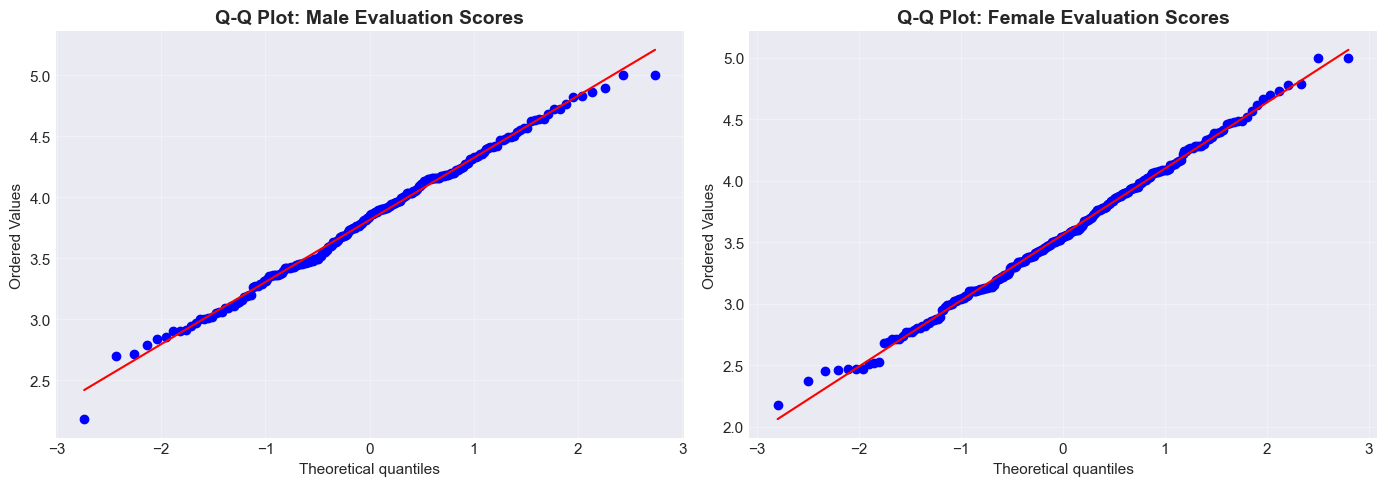


Interpretation: If points fall approximately on the red line, data is normally distributed.


In [9]:
# Visual check: Q-Q plots
from scipy import stats as sp_stats

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Q-Q plot for males
sp_stats.probplot(male_eval, dist="norm", plot=axes[0])
axes[0].set_title("Q-Q Plot: Male Evaluation Scores", fontsize=14, fontweight='bold')
axes[0].grid(True, alpha=0.3)

# Q-Q plot for females
sp_stats.probplot(female_eval, dist="norm", plot=axes[1])
axes[1].set_title("Q-Q Plot: Female Evaluation Scores", fontsize=14, fontweight='bold')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\nInterpretation: If points fall approximately on the red line, data is normally distributed.")

### Step 4: Perform Independent Samples t-Test

### Understanding the t-Test Calculation

The t-statistic measures how many standard errors the difference between group means is from zero.

**Step-by-step calculation**:
1. Calculate group means: $\bar{X}_1$, $\bar{X}_2$
2. Calculate group standard deviations: $s_1$, $s_2$
3. Calculate pooled standard deviation: $s_p$
4. Calculate standard error: $SE = s_p \sqrt{\frac{1}{n_1} + \frac{1}{n_2}}$
5. Calculate t-statistic: $t = \frac{\bar{X}_1 - \bar{X}_2}{SE}$
6. Find p-value from t-distribution with $df = n_1 + n_2 - 2$

**Interpretation**:
- Large |t| value: Groups are far apart relative to variability
- Small |t| value: Groups are close together relative to variability
- p-value < 0.05: Significant difference exists (reject H₀)

### **Step-by-Step t-Test Calculation Process**

Let's walk through the manual calculation of an independent samples t-test:

**Step 1: Calculate Group Means**
$$\bar{X}_1 = \frac{1}{n_1}\sum_{i=1}^{n_1} X_{1i} \quad \text{and} \quad \bar{X}_2 = \frac{1}{n_2}\sum_{i=1}^{n_2} X_{2i}$$

**Step 2: Calculate Group Standard Deviations**
$$s_1 = \sqrt{\frac{1}{n_1-1}\sum_{i=1}^{n_1}(X_{1i} - \bar{X}_1)^2} \quad \text{and} \quad s_2 = \sqrt{\frac{1}{n_2-1}\sum_{i=1}^{n_2}(X_{2i} - \bar{X}_2)^2}$$

**Step 3: Calculate Pooled Variance (if equal variances assumed)**
$$s_p^2 = \frac{(n_1-1)s_1^2 + (n_2-1)s_2^2}{n_1 + n_2 - 2}$$

This is a **weighted average** of the two sample variances, where the weights are the degrees of freedom.

**Step 4: Calculate Standard Error of Difference**
$$SE_{\bar{X}_1 - \bar{X}_2} = s_p\sqrt{\frac{1}{n_1} + \frac{1}{n_2}}$$

**Step 5: Calculate t-Statistic**
$$t = \frac{(\bar{X}_1 - \bar{X}_2) - (\mu_1 - \mu_2)}{SE_{\bar{X}_1 - \bar{X}_2}}$$

Under H₀: $\mu_1 = \mu_2$, so $(\mu_1 - \mu_2) = 0$:

$$t = \frac{\bar{X}_1 - \bar{X}_2}{s_p\sqrt{\frac{1}{n_1} + \frac{1}{n_2}}}$$

**Step 6: Determine Degrees of Freedom**
$$df = n_1 + n_2 - 2$$

**Step 7: Find Critical Value and P-value**
- Look up $t_{\alpha/2, df}$ from t-distribution table (for two-tailed test)
- Calculate p-value: $P(|T| \geq |t_{obs}|)$ where $T \sim t_{df}$

**Step 8: Make Decision**
- If $|t_{obs}| > t_{critical}$ or $p < \alpha$: Reject H₀
- If $|t_{obs}| \leq t_{critical}$ or $p \geq \alpha$: Fail to reject H₀

**Numerical Example:**
- Male mean = 4.0, Female mean = 4.2
- $s_1 = 0.5$, $s_2 = 0.6$
- $n_1 = 250$, $n_2 = 250$

$$s_p^2 = \frac{(250-1)(0.5)^2 + (250-1)(0.6)^2}{250 + 250 - 2} = \frac{62.25 + 89.64}{498} = 0.305$$

$$s_p = \sqrt{0.305} = 0.552$$

$$SE = 0.552\sqrt{\frac{1}{250} + \frac{1}{250}} = 0.552 \times 0.0894 = 0.0494$$

$$t = \frac{4.2 - 4.0}{0.0494} = \frac{0.2}{0.0494} = 4.05$$

With $df = 498$ and $\alpha = 0.05$, $t_{critical} = 1.96$

Since $|4.05| > 1.96$, we reject H₀.

In [12]:
# Check homogeneity of variance using Levene's test
from scipy.stats import levene

print("="*80)
print("HOMOGENEITY OF VARIANCE TEST (Levene's Test)")
print("="*80)

stat_levene, p_levene = levene(male_eval, female_eval)

print(f"\nLevene's Test:")
print(f"  Test statistic: {stat_levene:.6f}")
print(f"  p-value: {p_levene:.6f}")
print(f"  Conclusion: {'Equal variances (p > 0.05)' if p_levene > 0.05 else 'Unequal variances (p < 0.05)'}")

# Variance ratio check
variance_ratio = male_eval.var() / female_eval.var()
print(f"\nVariance Ratio (Male/Female): {variance_ratio:.4f}")
print(f"  Rule of thumb: Ratio < 4 suggests homogeneity")
conclusion = 'Homogeneity assumption satisfied' if variance_ratio < 4 and variance_ratio > 0.25 else "Consider using Welch's t-test"
print(f"  Conclusion: {conclusion}")

HOMOGENEITY OF VARIANCE TEST (Levene's Test)

Levene's Test:
  Test statistic: 0.381890
  p-value: 0.536879
  Conclusion: Equal variances (p > 0.05)

Variance Ratio (Male/Female): 0.9006
  Rule of thumb: Ratio < 4 suggests homogeneity
  Conclusion: Homogeneity assumption satisfied


### Step 5: Calculate Effect Size (Cohen's d)

### Understanding Cohen's d

Cohen's d is the **effect size** measure for t-tests. While p-values tell us if a difference exists, Cohen's d tells us how large that difference is.

**Formula**:
$$d = \frac{\bar{X}_1 - \bar{X}_2}{s_p}$$

**Interpretation**:
- It expresses the mean difference in standard deviation units
- Example: d = 0.5 means groups differ by half a standard deviation
- d = 0.8 means groups differ by 0.8 standard deviations (large effect)

**Why Effect Size Matters**:
- Statistical significance (p-value) depends on sample size
- Large samples can find tiny, meaningless differences significant
- Effect size tells us if the difference is practically important
- Always report both p-value and effect size

### **Detailed Interpretation of Effect Sizes**

Effect sizes tell us the **practical significance** of our findings, independent of sample size.

**Cohen's d (for t-tests):**

$$d = \frac{\bar{X}_1 - \bar{X}_2}{s_p}$$

where $s_p$ is the pooled standard deviation.

**Interpretation Guidelines:**
- |d| = 0.2: **Small effect** - Detectable only statistically
  - Example: 0.2 SD difference between groups
  - Real-world: Noticeable to researchers, not obvious to casual observers
  
- |d| = 0.5: **Medium effect** - Visible to the naked eye
  - Example: 0.5 SD difference between groups
  - Real-world: Obvious difference when groups are compared
  
- |d| = 0.8: **Large effect** - Substantial practical importance
  - Example: 0.8 SD difference between groups
  - Real-world: Difference is unmistakable and practically significant

**What does d = 0.5 mean practically?**
- The means differ by half a standard deviation
- There's approximately 67% non-overlap between distributions
- If you randomly select one person from each group, there's a 64% chance the person from the higher-scoring group will have a higher score

**Eta-squared (η²) for ANOVA:**

$$\eta^2 = \frac{SSB}{SST} = \frac{\text{Variance Between Groups}}{\text{Total Variance}}$$

**Interpretation:**
- η² = 0.01: **Small effect** - Group membership explains 1% of variance
- η² = 0.06: **Medium effect** - Group membership explains 6% of variance
- η² = 0.14: **Large effect** - Group membership explains 14% of variance

**Example:** η² = 0.08 means:
- 8% of variance in the outcome is due to group differences
- 92% of variance is due to other factors (individual differences, measurement error)
- This is considered a **medium effect**

**Cramér's V (for chi-square):**

$$V = \sqrt{\frac{\chi^2}{N \times \min(r-1, c-1)}}$$

**For 2×2 tables:**
- V = 0.10: **Small effect** - Weak association
- V = 0.30: **Medium effect** - Moderate association
- V = 0.50: **Large effect** - Strong association

**Example:** V = 0.15 means:
- Weak to moderate association between variables
- Knowing one variable provides limited information about the other
- The relationship exists but isn't strong enough for practical prediction

**R² (Coefficient of Determination):**

$$R^2 = r^2$$

**Interpretation:**
- R² = 0.01: **1% of variance explained** - Very weak relationship
- R² = 0.09: **9% of variance explained** - Weak relationship  
- R² = 0.25: **25% of variance explained** - Moderate relationship
- R² = 0.64: **64% of variance explained** - Strong relationship

**Example:** r = 0.6, R² = 0.36 means:
- 36% of variance in Y is predictable from X
- 64% of variance is due to other factors
- This represents a **moderate to strong** relationship

**Why Effect Sizes Matter:**
1. **Sample Size Independence:** P-values depend on sample size; effect sizes don't
2. **Practical Significance:** Statistical significance ≠ practical importance
3. **Comparability:** Can compare effects across studies
4. **Meta-Analysis:** Essential for combining studies
5. **Power Analysis:** Used to determine required sample sizes

**Common Mistake:**
Relying only on p-values without considering effect sizes can lead to:
- **Significant but trivial findings** (large sample, small effect)
- **Practically important but non-significant findings** (small sample, large effect)

In [13]:
# Perform independent samples t-test
print("="*80)
print("INDEPENDENT SAMPLES T-TEST")
print("="*80)

# Standard t-test (equal variances)
t_stat, p_value = ttest_ind(male_eval, female_eval)

# Welch's t-test (unequal variances - more robust)
t_stat_welch, p_value_welch = ttest_ind(male_eval, female_eval, equal_var=False)

print(f"\nStandard t-test (equal variances assumed):")
print(f"  t-statistic: {t_stat:.6f}")
print(f"  p-value: {p_value:.6f}")
print(f"  Degrees of freedom: {len(male_eval) + len(female_eval) - 2}")

print(f"\nWelch's t-test (unequal variances, more robust):")
print(f"  t-statistic: {t_stat_welch:.6f}")
print(f"  p-value: {p_value_welch:.6f}")

# Decision
alpha = 0.05
print(f"\n{'='*80}")
print("STATISTICAL DECISION")
print(f"{'='*80}")
print(f"Significance level: α = {alpha}")
if p_value_welch < alpha:
    print(f"Decision: REJECT H₀ (p = {p_value_welch:.4f} < {alpha})")
    print("Conclusion: There IS a statistically significant difference in mean evaluation scores between genders.")
else:
    print(f"Decision: FAIL TO REJECT H₀ (p = {p_value_welch:.4f} ≥ {alpha})")
    print("Conclusion: There is NO statistically significant difference in mean evaluation scores between genders.")

INDEPENDENT SAMPLES T-TEST

Standard t-test (equal variances assumed):
  t-statistic: 5.285554
  p-value: 0.000000
  Degrees of freedom: 493

Welch's t-test (unequal variances, more robust):
  t-statistic: 5.311925
  p-value: 0.000000

STATISTICAL DECISION
Significance level: α = 0.05
Decision: REJECT H₀ (p = 0.0000 < 0.05)
Conclusion: There IS a statistically significant difference in mean evaluation scores between genders.


### Step 6: Visualization

In [14]:
# Calculate Cohen's d effect size
pooled_std = np.sqrt(((len(male_eval)-1) * male_eval.var() + (len(female_eval)-1) * female_eval.var()) /
                      (len(male_eval) + len(female_eval) - 2))
cohens_d = (male_eval.mean() - female_eval.mean()) / pooled_std

print("="*80)
print("EFFECT SIZE (Cohen's d)")
print("="*80)
print(f"\nCohen's d: {cohens_d:.6f}")
print(f"Pooled standard deviation: {pooled_std:.6f}")

# Interpretation
if abs(cohens_d) < 0.2:
    effect_interp = "negligible"
elif abs(cohens_d) < 0.5:
    effect_interp = "small"
elif abs(cohens_d) < 0.8:
    effect_interp = "medium"
else:
    effect_interp = "large"

print(f"\nEffect Size Interpretation:")
print(f"  |d| < 0.2: Negligible effect")
print(f"  0.2 ≤ |d| < 0.5: Small effect")
print(f"  0.5 ≤ |d| < 0.8: Medium effect")
print(f"  |d| ≥ 0.8: Large effect")
print(f"\n  → This represents a {effect_interp.upper()} effect size")

# Practical significance
mean_diff = male_eval.mean() - female_eval.mean()
print(f"\nMean Difference: {mean_diff:.4f} points")
print(f"  Males {'score higher' if mean_diff > 0 else 'score lower'} than females by {abs(mean_diff):.4f} points on average")

# Confidence interval for the difference
from scipy.stats import t as t_dist
se_diff = pooled_std * np.sqrt(1/len(male_eval) + 1/len(female_eval))
df = len(male_eval) + len(female_eval) - 2
t_critical = t_dist.ppf(0.975, df)
ci_lower = mean_diff - t_critical * se_diff
ci_upper = mean_diff + t_critical * se_diff

print(f"\n95% Confidence Interval for Mean Difference:")
print(f"  [{ci_lower:.4f}, {ci_upper:.4f}]")
print(f"  Interpretation: We are 95% confident that the true difference in means lies within this interval.")

EFFECT SIZE (Cohen's d)

Cohen's d: 0.477292
Pooled standard deviation: 0.521486

Effect Size Interpretation:
  |d| < 0.2: Negligible effect
  0.2 ≤ |d| < 0.5: Small effect
  0.5 ≤ |d| < 0.8: Medium effect
  |d| ≥ 0.8: Large effect

  → This represents a SMALL effect size

Mean Difference: 0.2489 points
  Males score higher than females by 0.2489 points on average

95% Confidence Interval for Mean Difference:
  [0.1564, 0.3414]
  Interpretation: We are 95% confident that the true difference in means lies within this interval.


### Step 7: Statistical Conclusion and Interpretation

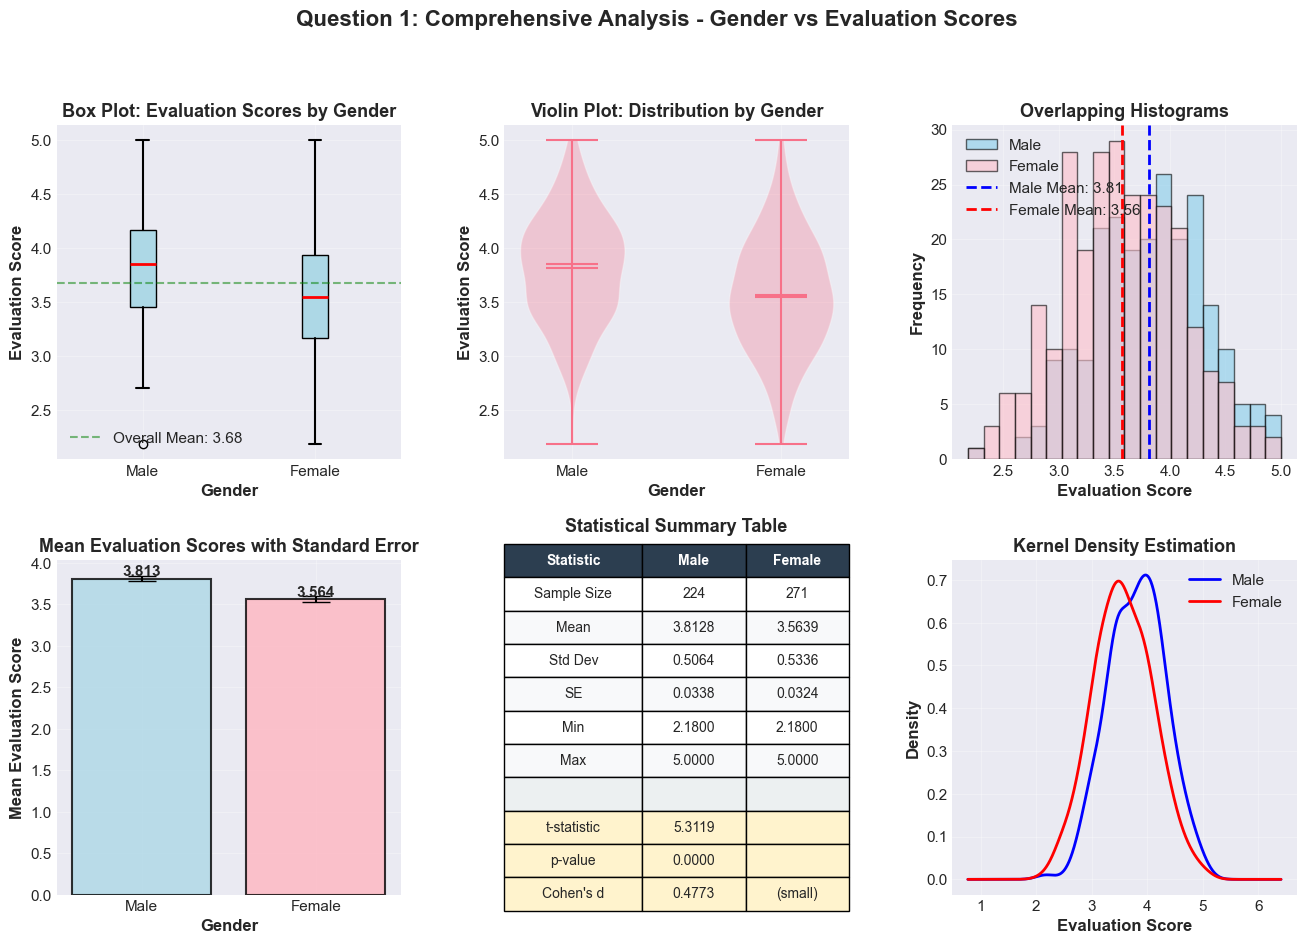

In [17]:
# Comprehensive visualizations for Question 1
fig = plt.figure(figsize=(16, 10))
from matplotlib.gridspec import GridSpec
gs = GridSpec(2, 3, figure=fig, hspace=0.3, wspace=0.3)

# 1. Box plot comparison
ax1 = fig.add_subplot(gs[0, 0])
box_data = [male_eval, female_eval]
bp = ax1.boxplot(box_data, labels=['Male', 'Female'], patch_artist=True,
                 medianprops=dict(color='red', linewidth=2),
                 boxprops=dict(facecolor='lightblue', edgecolor='black'),
                 whiskerprops=dict(color='black', linewidth=1.5),
                 capprops=dict(color='black', linewidth=1.5))
ax1.set_ylabel('Evaluation Score', fontsize=12, fontweight='bold')
ax1.set_xlabel('Gender', fontsize=12, fontweight='bold')
ax1.set_title('Box Plot: Evaluation Scores by Gender', fontsize=13, fontweight='bold')
ax1.grid(True, alpha=0.3, axis='y')
overall_mean = df_clean['eval_score'].mean()
ax1.axhline(y=overall_mean, color='green', linestyle='--', alpha=0.5, label=f'Overall Mean: {overall_mean:.2f}')
ax1.legend()

# 2. Violin plot
ax2 = fig.add_subplot(gs[0, 1])
parts = ax2.violinplot([male_eval, female_eval], positions=[1, 2], showmeans=True, showmedians=True)
ax2.set_xticks([1, 2])
ax2.set_xticklabels(['Male', 'Female'])
ax2.set_ylabel('Evaluation Score', fontsize=12, fontweight='bold')
ax2.set_xlabel('Gender', fontsize=12, fontweight='bold')
ax2.set_title('Violin Plot: Distribution by Gender', fontsize=13, fontweight='bold')
ax2.grid(True, alpha=0.3, axis='y')

# 3. Overlapping histograms
ax3 = fig.add_subplot(gs[0, 2])
ax3.hist(male_eval, bins=20, alpha=0.6, label='Male', color='skyblue', edgecolor='black')
ax3.hist(female_eval, bins=20, alpha=0.6, label='Female', color='pink', edgecolor='black')
ax3.axvline(male_eval.mean(), color='blue', linestyle='--', linewidth=2, label=f'Male Mean: {male_eval.mean():.2f}')
ax3.axvline(female_eval.mean(), color='red', linestyle='--', linewidth=2, label=f'Female Mean: {female_eval.mean():.2f}')
ax3.set_xlabel('Evaluation Score', fontsize=12, fontweight='bold')
ax3.set_ylabel('Frequency', fontsize=12, fontweight='bold')
ax3.set_title('Overlapping Histograms', fontsize=13, fontweight='bold')
ax3.legend()
ax3.grid(True, alpha=0.3)

# 4. Bar plot with error bars
ax4 = fig.add_subplot(gs[1, 0])
means = [male_eval.mean(), female_eval.mean()]
sems = [male_eval.sem(), female_eval.sem()]
colors = ['lightblue', 'lightpink']
bars = ax4.bar(['Male', 'Female'], means, yerr=sems, capsize=10, color=colors, edgecolor='black', linewidth=1.5, alpha=0.8)
for i, (bar, mean) in enumerate(zip(bars, means)):
    ax4.text(bar.get_x() + bar.get_width()/2, mean, f'{mean:.3f}', ha='center', va='bottom', fontweight='bold')
ax4.set_ylabel('Mean Evaluation Score', fontsize=12, fontweight='bold')
ax4.set_xlabel('Gender', fontsize=12, fontweight='bold')
ax4.set_title('Mean Evaluation Scores with Standard Error', fontsize=13, fontweight='bold')
ax4.grid(True, alpha=0.3, axis='y')

# 5. Statistical summary table
ax5 = fig.add_subplot(gs[1, 1])
ax5.axis('off')
summary_data = [
    ['Statistic', 'Male', 'Female'],
    ['Sample Size', f'{len(male_eval)}', f'{len(female_eval)}'],
    ['Mean', f'{male_eval.mean():.4f}', f'{female_eval.mean():.4f}'],
    ['Std Dev', f'{male_eval.std():.4f}', f'{female_eval.std():.4f}'],
    ['SE', f'{male_eval.sem():.4f}', f'{female_eval.sem():.4f}'],
    ['Min', f'{male_eval.min():.4f}', f'{female_eval.min():.4f}'],
    ['Max', f'{male_eval.max():.4f}', f'{female_eval.max():.4f}'],
    ['', '', ''],
    ['t-statistic', f'{t_stat_welch:.4f}', ''],
    ['p-value', f'{p_value_welch:.4f}', ''],
    ["Cohen's d", f'{cohens_d:.4f}', f'({effect_interp})'],
]
table = ax5.table(cellText=summary_data, cellLoc='center', loc='center', colWidths=[0.4, 0.3, 0.3])
table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1, 2)
for i in range(3):
    table[(0, i)].set_facecolor('#2C3E50')
    table[(0, i)].set_text_props(weight='bold', color='white')
for i in range(1, len(summary_data)):
    for j in range(3):
        if i == 7:
            table[(i, j)].set_facecolor('#ECF0F1')
        elif i > 7:
            table[(i, j)].set_facecolor('#FFF3CD')
        elif i % 2 == 0:
            table[(i, j)].set_facecolor('#F8F9FA')
ax5.set_title('Statistical Summary Table', fontsize=13, fontweight='bold', pad=20)

# 6. Density plots
ax6 = fig.add_subplot(gs[1, 2])
male_eval.plot(kind='density', ax=ax6, label='Male', color='blue', linewidth=2)
female_eval.plot(kind='density', ax=ax6, label='Female', color='red', linewidth=2)
ax6.set_xlabel('Evaluation Score', fontsize=12, fontweight='bold')
ax6.set_ylabel('Density', fontsize=12, fontweight='bold')
ax6.set_title('Kernel Density Estimation', fontsize=13, fontweight='bold')
ax6.legend()
ax6.grid(True, alpha=0.3)

plt.suptitle('Question 1: Comprehensive Analysis - Gender vs Evaluation Scores',
             fontsize=16, fontweight='bold', y=0.995)
plt.show()

---

# Question 2: ANOVA - Does Beauty Score Differ by Age?

## Problem Statement
Using the teachers' rating dataset, does beauty score for instructors differ by age?

## Approach
1. Create age groups for ANOVA analysis
2. State hypotheses
3. Check assumptions:
   - Independence of observations
   - Normality within groups
   - Homogeneity of variances
4. Perform one-way ANOVA
5. If significant, perform post-hoc tests
6. Calculate effect size (eta-squared)
7. Visualize results
8. Interpret findings

---

## Statistical Theory: One-Way ANOVA

### What is ANOVA?
**AN**alysis **O**f **VA**riance (ANOVA) is used to compare means across **three or more** independent groups. It tests whether at least one group mean differs from the others.

### Why Not Multiple t-Tests?
Performing multiple t-tests increases **Type I error rate** (false positives):
- 3 groups = 3 comparisons: α increases from 0.05 to ~0.14
- 4 groups = 6 comparisons: α increases to ~0.26
- ANOVA controls the overall α at 0.05

### Mathematical Formulation

ANOVA partitions total variance into:
1. **Between-group variance** (SSB): Variation due to group differences
2. **Within-group variance** (SSW): Variation within groups (error)

$$F = \frac{MS_B}{MS_W} = \frac{SS_B / df_B}{SS_W / df_W}$$

Where:
- $SS_B = \sum_{i=1}^{k} n_i(\bar{X}_i - \bar{X}_{grand})^2$ (between-group sum of squares)
- $SS_W = \sum_{i=1}^{k} \sum_{j=1}^{n_i} (X_{ij} - \bar{X}_i)^2$ (within-group sum of squares)
- $df_B = k - 1$ (k = number of groups)
- $df_W = N - k$ (N = total sample size)

### F-Distribution
- F-statistic follows an F-distribution with $(df_B, df_W)$ degrees of freedom
- Large F: Between-group variance >> Within-group variance → groups differ
- Small F: Between-group variance ≈ Within-group variance → groups similar

### Assumptions
1. **Independence**: Observations are independent
2. **Normality**: Data in each group is approximately normal
3. **Homogeneity of variances**: Variances are equal across all groups

### Effect Size: Eta-Squared (η²)
Measures proportion of total variance explained by group membership:

$$\eta^2 = \frac{SS_B}{SS_T} = \frac{SS_B}{SS_B + SS_W}$$

**Interpretation**:
- η² < 0.01: negligible effect
- 0.01 ≤ η² < 0.06: small effect
- 0.06 ≤ η² < 0.14: medium effect
- η² ≥ 0.14: large effect

### Post-Hoc Tests
If ANOVA is significant, perform **post-hoc pairwise comparisons** to identify which specific groups differ:
- **Bonferroni correction**: Adjust α for multiple comparisons (α_adjusted = α / number of comparisons)
- **Tukey's HSD**: Controls family-wise error rate
- **Scheffé's test**: Most conservative

### Non-Parametric Alternative
**Kruskal-Wallis test**: Used when normality assumption is violated. Tests whether groups have different distributions (not just means).

### Step 1: Create Age Groups

In [19]:
# Question 2: One-Way ANOVA Setup
print("="*80)
print("QUESTION 2: Do Beauty Scores Differ Across Age Groups?")
print("="*80)
print("\nHypotheses:")
print("H₀ (Null): μ₁ = μ₂ = μ₃ (All age group means are equal)")
print("H₁ (Alternative): At least one age group mean differs from the others")
print("\nSignificance level: α = 0.05")
print("Test type: One-way ANOVA")

# Reload the dataset (since df was overwritten as degrees of freedom)
df_original = pd.read_csv(path)

# Create age groups
df_clean_anova = df_original[['age', 'beauty']].dropna()

# Define age groups
bins = [df_clean_anova['age'].min()-1, 40, 50, df_clean_anova['age'].max()+1]
labels = ['Below 40', '40-50', 'Above 50']
df_clean_anova['age_group'] = pd.cut(df_clean_anova['age'], bins=bins, labels=labels)

# Separate data by age group
below_40 = df_clean_anova[df_clean_anova['age_group'] == 'Below 40']['beauty']
age_40_50 = df_clean_anova[df_clean_anova['age_group'] == '40-50']['beauty']
above_50 = df_clean_anova[df_clean_anova['age_group'] == 'Above 50']['beauty']

print(f"\nData Summary by Age Group:")
print(f"Below 40: n = {len(below_40)}, Mean = {below_40.mean():.3f}, SD = {below_40.std():.3f}")
print(f"40-50: n = {len(age_40_50)}, Mean = {age_40_50.mean():.3f}, SD = {age_40_50.std():.3f}")
print(f"Above 50: n = {len(above_50)}, Mean = {above_50.mean():.3f}, SD = {above_50.std():.3f}")

QUESTION 2: Do Beauty Scores Differ Across Age Groups?

Hypotheses:
H₀ (Null): μ₁ = μ₂ = μ₃ (All age group means are equal)
H₁ (Alternative): At least one age group mean differs from the others

Significance level: α = 0.05
Test type: One-way ANOVA

Data Summary by Age Group:
Below 40: n = 188, Mean = -0.027, SD = 0.946
40-50: n = 185, Mean = 0.030, SD = 0.969
Above 50: n = 117, Mean = 0.049, SD = 1.103


### Step 2: State Hypotheses

In [20]:
# Check assumptions for ANOVA
print("="*80)
print("ASSUMPTION CHECKS")
print("="*80)

# Normality for each group
print("\n1. Normality Test (Shapiro-Wilk):")
for name, data in [('Below 40', below_40), ('40-50', age_40_50), ('Above 50', above_50)]:
    stat, p = shapiro(data)
    print(f"  {name}: W = {stat:.6f}, p = {p:.6f} - {'Normal' if p > 0.05 else 'Not normal'}")

# Homogeneity of variances
print("\n2. Homogeneity of Variances (Levene's Test):")
stat_lev, p_lev = levene(below_40, age_40_50, above_50)
print(f"  F = {stat_lev:.6f}, p = {p_lev:.6f} - {'Equal variances' if p_lev > 0.05 else 'Unequal variances'}")

ASSUMPTION CHECKS

1. Normality Test (Shapiro-Wilk):
  Below 40: W = 0.993430, p = 0.567174 - Normal
  40-50: W = 0.987622, p = 0.105572 - Normal
  Above 50: W = 0.987406, p = 0.351192 - Normal

2. Homogeneity of Variances (Levene's Test):
  F = 2.745681, p = 0.065199 - Equal variances


### Step 3: Check Assumptions

#### Assumption 1: Independence (satisfied by design)

#### Assumption 2: Normality within Groups

In [21]:
# Perform one-way ANOVA
print("="*80)
print("ONE-WAY ANOVA TEST")
print("="*80)

f_stat, p_value_anova = f_oneway(below_40, age_40_50, above_50)

print(f"\nF-statistic: {f_stat:.6f}")
print(f"p-value: {p_value_anova:.6f}")
print(f"Degrees of freedom: df_between = 2, df_within = {len(df_clean_anova)-3}")

# Decision
alpha = 0.05
print(f"\n{'='*80}")
print("STATISTICAL DECISION")
print(f"{'='*80}")
print(f"Significance level: α = {alpha}")
if p_value_anova < alpha:
    print(f"Decision: REJECT H₀ (p = {p_value_anova:.4f} < {alpha})")
    print("Conclusion: At least one age group has a significantly different mean beauty score.")
else:
    print(f"Decision: FAIL TO REJECT H₀ (p = {p_value_anova:.4f} ≥ {alpha})")
    print("Conclusion: No significant difference in mean beauty scores across age groups.")

ONE-WAY ANOVA TEST

F-statistic: 0.260635
p-value: 0.770669
Degrees of freedom: df_between = 2, df_within = 487

STATISTICAL DECISION
Significance level: α = 0.05
Decision: FAIL TO REJECT H₀ (p = 0.7707 ≥ 0.05)
Conclusion: No significant difference in mean beauty scores across age groups.


#### Assumption 3: Homogeneity of Variances

In [22]:
# Calculate effect size (Eta-squared)
print("="*80)
print("EFFECT SIZE (Eta-Squared)")
print("="*80)

# Calculate sum of squares
grand_mean = df_clean_anova['beauty'].mean()
ssb = sum(len(group) * (group.mean() - grand_mean)**2
          for group in [below_40, age_40_50, above_50])
sst = sum((df_clean_anova['beauty'] - grand_mean)**2)
eta_squared = ssb / sst

print(f"\nEta-squared (η²): {eta_squared:.6f}")
print(f"  {eta_squared*100:.2f}% of variance in beauty scores is explained by age group")

if eta_squared < 0.01:
    effect_size_interp = "negligible"
elif eta_squared < 0.06:
    effect_size_interp = "small"
elif eta_squared < 0.14:
    effect_size_interp = "medium"
else:
    effect_size_interp = "large"

print(f"  Effect size interpretation: {effect_size_interp.upper()}")

EFFECT SIZE (Eta-Squared)

Eta-squared (η²): 0.001069
  0.11% of variance in beauty scores is explained by age group
  Effect size interpretation: NEGLIGIBLE


### Step 4: Perform One-Way ANOVA

### Understanding the ANOVA F-Statistic

The F-statistic is the ratio of **systematic variance** to **random variance**:

$$F = \frac{\text{Variance between groups}}{\text{Variance within groups}} = \frac{\text{Signal}}{\text{Noise}}$$

**Intuition**:
- If groups have different means, between-group variance will be large → Large F
- If groups overlap, between-group variance will be small → Small F
- F ≈ 1: Group means are similar (H₀ likely true)
- F >> 1: At least one group differs (H₀ likely false)

**ANOVA Table Structure**:

| Source | SS | df | MS | F |
|--------|----|----|----|----|
| Between | SSB | k-1 | SSB/(k-1) | MSB/MSW |
| Within | SSW | N-k | SSW/(N-k) | - |
| Total | SST | N-1 | - | - |

### **Step-by-Step ANOVA Calculation Process**

Let's manually calculate a one-way ANOVA:

**Given Data Structure:**
- Group 1 (Below 40): $n_1$ observations, values $X_{11}, X_{12}, ..., X_{1n_1}$
- Group 2 (40-50): $n_2$ observations, values $X_{21}, X_{22}, ..., X_{2n_2}$
- Group 3 (Above 50): $n_3$ observations, values $X_{31}, X_{32}, ..., X_{3n_3}$
- Total observations: $N = n_1 + n_2 + n_3$

**Step 1: Calculate Group Means**
$$\bar{X}_j = \frac{1}{n_j}\sum_{i=1}^{n_j} X_{ji} \quad \text{for } j = 1, 2, 3$$

**Step 2: Calculate Grand Mean**
$$\bar{X}_{\cdot\cdot} = \frac{1}{N}\sum_{j=1}^{3}\sum_{i=1}^{n_j} X_{ji} = \frac{n_1\bar{X}_1 + n_2\bar{X}_2 + n_3\bar{X}_3}{N}$$

**Step 3: Calculate Sum of Squares Between Groups (SSB)**
$$SSB = \sum_{j=1}^{3} n_j(\bar{X}_j - \bar{X}_{\cdot\cdot})^2$$

This measures **variation between group means**.

**Step 4: Calculate Sum of Squares Within Groups (SSW)**
$$SSW = \sum_{j=1}^{3}\sum_{i=1}^{n_j}(X_{ji} - \bar{X}_j)^2$$

This measures **variation within each group** (pooled).

**Step 5: Calculate Total Sum of Squares (SST)**
$$SST = \sum_{j=1}^{3}\sum_{i=1}^{n_j}(X_{ji} - \bar{X}_{\cdot\cdot})^2$$

**Verification:** $SST = SSB + SSW$

**Step 6: Calculate Degrees of Freedom**
- Between groups: $df_B = k - 1 = 3 - 1 = 2$ (where $k$ = number of groups)
- Within groups: $df_W = N - k = N - 3$
- Total: $df_T = N - 1$

**Step 7: Calculate Mean Squares**
$$MSB = \frac{SSB}{df_B} \quad \text{(Between-group variance)}$$

$$MSW = \frac{SSW}{df_W} \quad \text{(Within-group variance, pooled)}$$

**Step 8: Calculate F-Statistic**
$$F = \frac{MSB}{MSW}$$

**Interpretation:**
- $F \approx 1$: Group means are similar (variation between ≈ variation within)
- $F >> 1$: Group means differ significantly (variation between >> variation within)

**Step 9: Find Critical Value and P-value**
- Compare $F_{obs}$ to $F_{\alpha, df_B, df_W}$ from F-distribution table
- Calculate p-value: $P(F_{df_B, df_W} \geq F_{obs})$

**Step 10: Calculate Effect Size (Eta-squared)**
$$\eta^2 = \frac{SSB}{SST}$$

This is the **proportion of total variance** explained by group membership.

**Numerical Example:**
Suppose we have:
- Group 1 (Below 40): $n_1 = 150$, $\bar{X}_1 = 3.8$, $s_1^2 = 0.4$
- Group 2 (40-50): $n_2 = 200$, $\bar{X}_2 = 4.0$, $s_2^2 = 0.5$
- Group 3 (Above 50): $n_3 = 150$, $\bar{X}_3 = 4.2$, $s_3^2 = 0.45$
- Grand mean: $\bar{X}_{\cdot\cdot} = \frac{150(3.8) + 200(4.0) + 150(4.2)}{500} = 4.0$

**Calculate SSB:**
$$SSB = 150(3.8-4.0)^2 + 200(4.0-4.0)^2 + 150(4.2-4.0)^2$$
$$SSB = 150(0.04) + 0 + 150(0.04) = 6 + 0 + 6 = 12$$

**Calculate SSW:**
$$SSW = (n_1-1)s_1^2 + (n_2-1)s_2^2 + (n_3-1)s_3^2$$
$$SSW = 149(0.4) + 199(0.5) + 149(0.45) = 59.6 + 99.5 + 67.05 = 226.15$$

**Calculate F:**
$$MSB = \frac{12}{2} = 6.0$$
$$MSW = \frac{226.15}{497} = 0.455$$
$$F = \frac{6.0}{0.455} = 13.19$$

With $df_1 = 2, df_2 = 497$, and $\alpha = 0.05$, $F_{critical} \approx 3.0$

Since $13.19 > 3.0$, we reject H₀.

**Effect size:**
$$\eta^2 = \frac{12}{12 + 226.15} = \frac{12}{238.15} = 0.050 \text{ (5%)}$$

In [24]:
# Post-hoc tests: Bonferroni pairwise comparisons
if p_value_anova < 0.05:
    print("="*80)
    print("POST-HOC TESTS (Bonferroni-corrected pairwise comparisons)")
    print("="*80)

    from scipy.stats import ttest_ind

    # Number of comparisons
    num_comparisons = 3
    alpha_bonf = alpha / num_comparisons

    print(f"\nAdjusted significance level (Bonferroni): α = {alpha_bonf:.4f}")
    print(f"\nPairwise Comparisons:")

    comparisons = [
        ('Below 40', 'Age 40-50', below_40, age_40_50),
        ('Below 40', 'Above 50', below_40, above_50),
        ('Age 40-50', 'Above 50', age_40_50, above_50)
    ]

    for name1, name2, data1, data2 in comparisons:
        t, p = ttest_ind(data1, data2)
        print(f"\n  {name1} vs {name2}:")
        print(f"    t = {t:.4f}, p = {p:.4f}")
        print(f"    {'SIGNIFICANT' if p < alpha_bonf else 'Not significant'} (p {'<' if p < alpha_bonf else '≥'} {alpha_bonf:.4f})")

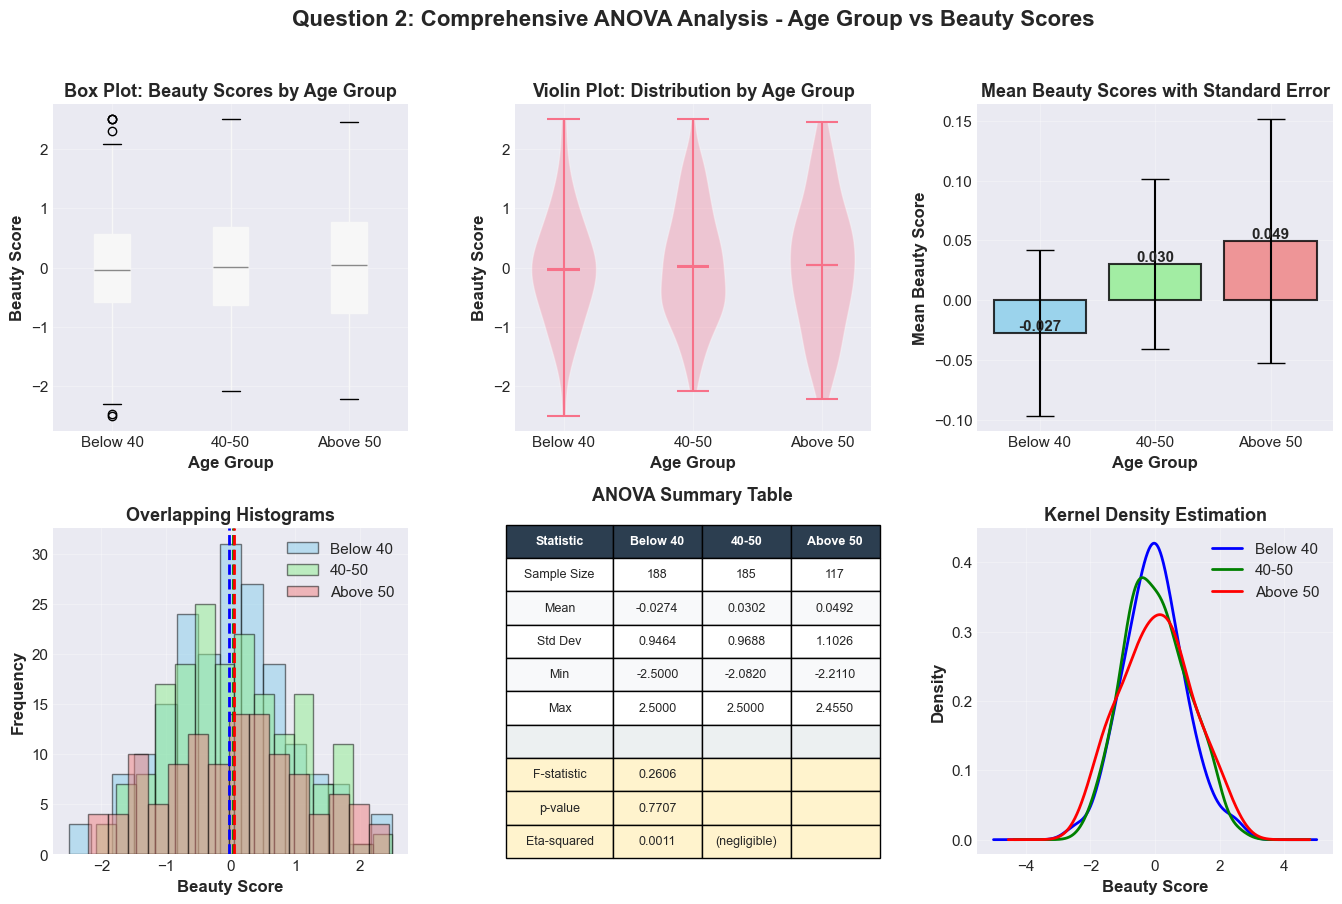

In [25]:
# Comprehensive visualizations for Question 2
fig = plt.figure(figsize=(16, 10))
gs = GridSpec(2, 3, figure=fig, hspace=0.3, wspace=0.3)

# 1. Box plot
ax1 = fig.add_subplot(gs[0, 0])
df_clean_anova.boxplot(column='beauty', by='age_group', ax=ax1, patch_artist=True)
ax1.set_xlabel('Age Group', fontsize=12, fontweight='bold')
ax1.set_ylabel('Beauty Score', fontsize=12, fontweight='bold')
ax1.set_title('Box Plot: Beauty Scores by Age Group', fontsize=13, fontweight='bold')
ax1.get_figure().suptitle('')  # Remove default title
plt.sca(ax1)
plt.xticks(rotation=0)
ax1.grid(True, alpha=0.3, axis='y')

# 2. Violin plot
ax2 = fig.add_subplot(gs[0, 1])
data_for_violin = [below_40, age_40_50, above_50]
parts = ax2.violinplot(data_for_violin, positions=[1, 2, 3], showmeans=True, showmedians=True)
ax2.set_xticks([1, 2, 3])
ax2.set_xticklabels(['Below 40', '40-50', 'Above 50'])
ax2.set_ylabel('Beauty Score', fontsize=12, fontweight='bold')
ax2.set_xlabel('Age Group', fontsize=12, fontweight='bold')
ax2.set_title('Violin Plot: Distribution by Age Group', fontsize=13, fontweight='bold')
ax2.grid(True, alpha=0.3, axis='y')

# 3. Bar plot with error bars
ax3 = fig.add_subplot(gs[0, 2])
means = [below_40.mean(), age_40_50.mean(), above_50.mean()]
sems = [below_40.sem(), age_40_50.sem(), above_50.sem()]
x_pos = np.arange(len(labels))
bars = ax3.bar(x_pos, means, yerr=sems, capsize=10, color=['skyblue', 'lightgreen', 'lightcoral'],
               edgecolor='black', linewidth=1.5, alpha=0.8)
ax3.set_xticks(x_pos)
ax3.set_xticklabels(labels, rotation=0)
ax3.set_ylabel('Mean Beauty Score', fontsize=12, fontweight='bold')
ax3.set_xlabel('Age Group', fontsize=12, fontweight='bold')
ax3.set_title('Mean Beauty Scores with Standard Error', fontsize=13, fontweight='bold')
for i, (bar, mean) in enumerate(zip(bars, means)):
    ax3.text(bar.get_x() + bar.get_width()/2, mean, f'{mean:.3f}', ha='center', va='bottom', fontweight='bold')
ax3.grid(True, alpha=0.3, axis='y')

# 4. Overlapping histograms
ax4 = fig.add_subplot(gs[1, 0])
ax4.hist(below_40, bins=15, alpha=0.5, label='Below 40', color='skyblue', edgecolor='black')
ax4.hist(age_40_50, bins=15, alpha=0.5, label='40-50', color='lightgreen', edgecolor='black')
ax4.hist(above_50, bins=15, alpha=0.5, label='Above 50', color='lightcoral', edgecolor='black')
ax4.axvline(below_40.mean(), color='blue', linestyle='--', linewidth=2)
ax4.axvline(age_40_50.mean(), color='green', linestyle='--', linewidth=2)
ax4.axvline(above_50.mean(), color='red', linestyle='--', linewidth=2)
ax4.set_xlabel('Beauty Score', fontsize=12, fontweight='bold')
ax4.set_ylabel('Frequency', fontsize=12, fontweight='bold')
ax4.set_title('Overlapping Histograms', fontsize=13, fontweight='bold')
ax4.legend()
ax4.grid(True, alpha=0.3)

# 5. Statistical summary table
ax5 = fig.add_subplot(gs[1, 1])
ax5.axis('off')
summary_data = [
    ['Statistic', 'Below 40', '40-50', 'Above 50'],
    ['Sample Size', f'{len(below_40)}', f'{len(age_40_50)}', f'{len(above_50)}'],
    ['Mean', f'{below_40.mean():.4f}', f'{age_40_50.mean():.4f}', f'{above_50.mean():.4f}'],
    ['Std Dev', f'{below_40.std():.4f}', f'{age_40_50.std():.4f}', f'{above_50.std():.4f}'],
    ['Min', f'{below_40.min():.4f}', f'{age_40_50.min():.4f}', f'{above_50.min():.4f}'],
    ['Max', f'{below_40.max():.4f}', f'{age_40_50.max():.4f}', f'{above_50.max():.4f}'],
    ['', '', '', ''],
    ['F-statistic', f'{f_stat:.4f}', '', ''],
    ['p-value', f'{p_value_anova:.4f}', '', ''],
    ['Eta-squared', f'{eta_squared:.4f}', f'({effect_size_interp})', ''],
]
table = ax5.table(cellText=summary_data, cellLoc='center', loc='center', colWidths=[0.3, 0.25, 0.25, 0.25])
table.auto_set_font_size(False)
table.set_fontsize(9)
table.scale(1, 2)
for i in range(4):
    table[(0, i)].set_facecolor('#2C3E50')
    table[(0, i)].set_text_props(weight='bold', color='white')
for i in range(1, len(summary_data)):
    for j in range(4):
        if i == 6:
            table[(i, j)].set_facecolor('#ECF0F1')
        elif i > 6:
            table[(i, j)].set_facecolor('#FFF3CD')
        elif i % 2 == 0:
            table[(i, j)].set_facecolor('#F8F9FA')
ax5.set_title('ANOVA Summary Table', fontsize=13, fontweight='bold', pad=20)

# 6. Density plots
ax6 = fig.add_subplot(gs[1, 2])
below_40.plot(kind='density', ax=ax6, label='Below 40', color='blue', linewidth=2)
age_40_50.plot(kind='density', ax=ax6, label='40-50', color='green', linewidth=2)
above_50.plot(kind='density', ax=ax6, label='Above 50', color='red', linewidth=2)
ax6.set_xlabel('Beauty Score', fontsize=12, fontweight='bold')
ax6.set_ylabel('Density', fontsize=12, fontweight='bold')
ax6.set_title('Kernel Density Estimation', fontsize=13, fontweight='bold')
ax6.legend()
ax6.grid(True, alpha=0.3)

plt.suptitle('Question 2: Comprehensive ANOVA Analysis - Age Group vs Beauty Scores',
             fontsize=16, fontweight='bold', y=0.995)
plt.show()

### Step 6: Post-hoc Tests (if ANOVA is significant)

### Understanding Post-Hoc Tests

When ANOVA is significant (p < 0.05), we know **at least one group differs**, but we don't know **which specific pairs** differ.

**Bonferroni Correction**:
- Problem: Multiple comparisons inflate Type I error
- Solution: Divide α by number of comparisons
- For 3 groups (3 comparisons): α_adjusted = 0.05/3 = 0.0167
- Conservative but protects against false positives

**Example with 3 Groups (Young, Middle, Senior)**:
1. Young vs Middle
2. Young vs Senior  
3. Middle vs Senior

Total comparisons = $\binom{k}{2} = \frac{k(k-1)}{2}$ where k = number of groups

**Interpretation**:
- Compare each pairwise p-value to α_adjusted
- Only reject H₀ if p < α_adjusted
- This controls the **family-wise error rate**

### **Detailed Post-Hoc Test Calculations**

When ANOVA finds significant differences, post-hoc tests identify **which specific groups differ**.

**Bonferroni Correction Method:**

**Problem:** Multiple comparisons increase Type I error rate (false positives).

With $k$ groups, there are $C = \binom{k}{2} = \frac{k(k-1)}{2}$ pairwise comparisons.

**Example:** 3 groups → $C = \frac{3(2)}{2} = 3$ comparisons:
1. Group 1 vs Group 2
2. Group 1 vs Group 3
3. Group 2 vs Group 3

**Family-Wise Error Rate (FWER):**

If each test uses $\alpha = 0.05$:
$$FWER = 1 - (1-\alpha)^C$$

For 3 comparisons:
$$FWER = 1 - (1-0.05)^3 = 1 - 0.857 = 0.143$$

**Problem:** 14.3% chance of at least one false positive (not 5%)!

**Bonferroni Solution:**

Adjust significance level for each comparison:
$$\alpha_{adj} = \frac{\alpha}{C}$$

For 3 comparisons with $\alpha = 0.05$:
$$\alpha_{adj} = \frac{0.05}{3} = 0.0167$$

**Now each test uses α = 0.0167, ensuring FWER ≤ 0.05**

**Step-by-Step Bonferroni Test:**

**Step 1: Perform All Pairwise t-Tests**

For groups $i$ and $j$:
$$t_{ij} = \frac{\bar{X}_i - \bar{X}_j}{MSW\sqrt{\frac{1}{n_i} + \frac{1}{n_j}}}$$

where $MSW$ comes from ANOVA (pooled variance).

**Step 2: Calculate P-values**

For each comparison, find $p_{ij} = P(|T_{df_W}| \geq |t_{ij}|)$

**Step 3: Compare to Adjusted Alpha**

Reject H₀ if $p_{ij} < \alpha_{adj} = \frac{\alpha}{C}$

**Numerical Example:**

Suppose we have 3 age groups (Below 40, 40-50, Above 50) with:
- $\bar{X}_1 = 3.8, \bar{X}_2 = 4.0, \bar{X}_3 = 4.2$
- $MSW = 0.455$ (from ANOVA)
- $n_1 = 150, n_2 = 200, n_3 = 150$
- $df_W = 497$

**Comparison 1: Below 40 vs 40-50**
$$SE = \sqrt{0.455\left(\frac{1}{150} + \frac{1}{200}\right)} = \sqrt{0.455(0.0117)} = 0.0729$$

$$t = \frac{3.8 - 4.0}{0.0729} = \frac{-0.2}{0.0729} = -2.74$$

$p = 0.0063$ (two-tailed)

**Comparison 2: Below 40 vs Above 50**
$$SE = \sqrt{0.455\left(\frac{1}{150} + \frac{1}{150}\right)} = \sqrt{0.455(0.0133)} = 0.0779$$

$$t = \frac{3.8 - 4.2}{0.0779} = \frac{-0.4}{0.0779} = -5.14$$

$p < 0.0001$ (two-tailed)

**Comparison 3: 40-50 vs Above 50**
$$SE = \sqrt{0.455\left(\frac{1}{200} + \frac{1}{150}\right)} = \sqrt{0.455(0.0117)} = 0.0729$$

$$t = \frac{4.0 - 4.2}{0.0729} = \frac{-0.2}{0.0729} = -2.74$$

$p = 0.0063$ (two-tailed)

**Apply Bonferroni Correction:**

$\alpha_{adj} = \frac{0.05}{3} = 0.0167$

**Decision:**
- Comparison 1: $p = 0.0063 < 0.0167$ → **Significant**
- Comparison 2: $p < 0.0001 < 0.0167$ → **Significant**
- Comparison 3: $p = 0.0063 < 0.0167$ → **Significant**

**Conclusion:** All three groups differ significantly from each other.

**Alternative: Tukey's HSD (Honest Significant Difference)**

More powerful than Bonferroni when making all pairwise comparisons:

$$HSD = q_{\alpha, k, df_W} \times \sqrt{\frac{MSW}{n_h}}$$

where:
- $q$ = studentized range statistic
- $n_h$ = harmonic mean of group sizes
- $k$ = number of groups

**Advantages of Tukey over Bonferroni:**
- More statistical power
- Specifically designed for all pairwise comparisons
- Better control of FWER for balanced designs

**When to Use Which:**
- **Bonferroni:** Simple, conservative, works for any comparisons
- **Tukey:** More powerful for all pairwise comparisons
- **Dunnett:** Comparing multiple groups to a single control
- **Scheffé:** Most conservative, for any conceivable comparison

In [28]:
# Question 3: Chi-square test - Gender vs Tenure status
print("="*80)
print("QUESTION 3: CHI-SQUARE TEST OF INDEPENDENCE")
print("="*80)

print("\nResearch Question:")
print("Is there a significant association between gender and tenure status?")

print("\n" + "-"*80)
print("HYPOTHESES")
print("-"*80)

print("\nNull Hypothesis (H₀):")
print("  Gender and tenure status are independent (no association)")
print("  P(Tenure | Gender) = P(Tenure)")

print("\nAlternative Hypothesis (H₁):")
print("  Gender and tenure status are associated (dependent)")
print("  P(Tenure | Gender) ≠ P(Tenure)")

print("\nSignificance Level: α = 0.05")

# Reload the dataset (since df was overwritten as degrees of freedom)
df_original = pd.read_csv(path)

# Create clean dataset (remove NaN values)
# Note: The column is 'tenured' not 'tenure' in the dataset
df_chi = df_original[['gender', 'tenured']].dropna()

print(f"\nSample size (after removing missing values): {len(df_chi)}")

QUESTION 3: CHI-SQUARE TEST OF INDEPENDENCE

Research Question:
Is there a significant association between gender and tenure status?

--------------------------------------------------------------------------------
HYPOTHESES
--------------------------------------------------------------------------------

Null Hypothesis (H₀):
  Gender and tenure status are independent (no association)
  P(Tenure | Gender) = P(Tenure)

Alternative Hypothesis (H₁):
  Gender and tenure status are associated (dependent)
  P(Tenure | Gender) ≠ P(Tenure)

Significance Level: α = 0.05

Sample size (after removing missing values): 500


### Step 7: Visualization

In [29]:
# Create contingency table
contingency_table = pd.crosstab(df_chi['gender'], df_chi['tenured'], margins=True, margins_name='Total')

print("="*80)
print("CONTINGENCY TABLE: Gender × Tenure Status")
print("="*80)
print("\nObserved Frequencies:")
print(contingency_table)

# Calculate row percentages
row_percentages = pd.crosstab(df_chi['gender'], df_chi['tenured'], normalize='index') * 100
print("\n" + "-"*80)
print("Row Percentages (% within each gender):")
print("-"*80)
print(row_percentages.round(2))

# Calculate column percentages
col_percentages = pd.crosstab(df_chi['gender'], df_chi['tenured'], normalize='columns') * 100
print("\n" + "-"*80)
print("Column Percentages (% within each tenure status):")
print("-"*80)
print(col_percentages.round(2))

# Store contingency table without margins for chi-square test
observed = pd.crosstab(df_chi['gender'], df_chi['tenured'])
print(f"\nContingency table shape: {observed.shape[0]} rows × {observed.shape[1]} columns")

CONTINGENCY TABLE: Gender × Tenure Status

Observed Frequencies:
tenured    0    1  Total
gender                  
female   128  144    272
male      70  158    228
Total    198  302    500

--------------------------------------------------------------------------------
Row Percentages (% within each gender):
--------------------------------------------------------------------------------
tenured      0      1
gender               
female   47.06  52.94
male     30.70  69.30

--------------------------------------------------------------------------------
Column Percentages (% within each tenure status):
--------------------------------------------------------------------------------
tenured      0      1
gender               
female   64.65  47.68
male     35.35  52.32

Contingency table shape: 2 rows × 2 columns


### Step 8: Statistical Conclusion and Interpretation

In [30]:
# Perform Chi-square test
from scipy.stats import chi2_contingency

print("="*80)
print("CHI-SQUARE TEST OF INDEPENDENCE")
print("="*80)

chi2_stat, p_value_chi, dof, expected = chi2_contingency(observed)

print(f"\nTest Statistic: χ² = {chi2_stat:.6f}")
print(f"Degrees of Freedom: df = {dof}")
print(f"p-value: p = {p_value_chi:.6f}")

print("\n" + "-"*80)
print("Expected Frequencies:")
print("-"*80)
expected_df = pd.DataFrame(expected, index=observed.index, columns=observed.columns)
print(expected_df.round(2))

# Check assumptions
print("\n" + "-"*80)
print("ASSUMPTION CHECK")
print("-"*80)
min_expected = expected.min()
cells_below_5 = (expected < 5).sum()
total_cells = expected.size

print(f"\nMinimum expected frequency: {min_expected:.2f}")
print(f"Number of cells with expected frequency < 5: {cells_below_5} out of {total_cells}")
print(f"Percentage of cells < 5: {(cells_below_5/total_cells)*100:.1f}%")
print(f"\nAssumption: {'SATISFIED' if min_expected >= 5 and cells_below_5/total_cells <= 0.20 else 'VIOLATED'}")
print("  (All expected frequencies should be ≥ 5, or at most 20% < 5)")

# Statistical decision
print("\n" + "="*80)
print("STATISTICAL DECISION")
print("="*80)
print(f"\nα = 0.05")
print(f"p-value = {p_value_chi:.6f}")
print(f"\nDecision: {'Reject H₀' if p_value_chi < 0.05 else 'Fail to reject H₀'}")
print(f"Conclusion: There {'IS' if p_value_chi < 0.05 else 'IS NO'} significant association between gender and tenure status")

CHI-SQUARE TEST OF INDEPENDENCE

Test Statistic: χ² = 13.198906
Degrees of Freedom: df = 1
p-value: p = 0.000280

--------------------------------------------------------------------------------
Expected Frequencies:
--------------------------------------------------------------------------------
tenured       0       1
gender                 
female   107.71  164.29
male      90.29  137.71

--------------------------------------------------------------------------------
ASSUMPTION CHECK
--------------------------------------------------------------------------------

Minimum expected frequency: 90.29
Number of cells with expected frequency < 5: 0 out of 4
Percentage of cells < 5: 0.0%

Assumption: SATISFIED
  (All expected frequencies should be ≥ 5, or at most 20% < 5)

STATISTICAL DECISION

α = 0.05
p-value = 0.000280

Decision: Reject H₀
Conclusion: There IS significant association between gender and tenure status


---

# Question 3: Chi-Square Test - Is There an Association Between Tenure and Gender?

## Problem Statement
Using the teachers' rating dataset, is there an association between tenure and gender?

## Approach
1. State hypotheses
2. Create contingency table
3. Check assumptions:
   - Independence of observations
   - Expected frequencies (all cells ≥ 5)
4. Perform chi-square test of independence
5. Calculate effect size (Cramér's V)
6. Visualize the relationship
7. Interpret results

---

## Statistical Theory: Chi-Square Test of Independence

### What is Chi-Square Test?
The chi-square (χ²) test of independence determines whether two categorical variables are associated (related) or independent.

### Mathematical Formulation

The chi-square statistic measures how much observed frequencies deviate from expected frequencies:

$$\chi^2 = \sum_{i=1}^{r} \sum_{j=1}^{c} \frac{(O_{ij} - E_{ij})^2}{E_{ij}}$$

Where:
- $O_{ij}$ = observed frequency in cell (i, j)
- $E_{ij}$ = expected frequency in cell (i, j)
- r = number of rows
- c = number of columns

### Expected Frequencies
Under the null hypothesis (independence), expected frequencies are calculated as:

$$E_{ij} = \frac{(\text{Row}_i \text{ total}) \times (\text{Column}_j \text{ total})}{\text{Grand total}}$$

### Degrees of Freedom
$$df = (r - 1) \times (c - 1)$$

For a 2×2 table: $df = (2-1) \times (2-1) = 1$

### Chi-Square Distribution
- χ² values are always positive (squared differences)
- Right-skewed distribution
- Large χ²: Observed differs greatly from expected → association exists
- Small χ²: Observed close to expected → variables independent

### Assumptions
1. **Independence**: Each observation belongs to only one cell
2. **Expected frequencies**: All expected frequencies ≥ 5
   - If violated, consider Fisher's exact test (for 2×2 tables)
   - Or combine categories to increase cell counts
3. **Sample size**: Sufficient sample size (typically n ≥ 20)

### Effect Size: Cramér's V
Measures strength of association for categorical variables:

$$V = \sqrt{\frac{\chi^2}{n \times \min(r-1, c-1)}}$$

For 2×2 tables, Cramér's V equals phi coefficient (φ):

$$\phi = \sqrt{\frac{\chi^2}{n}}$$

**Interpretation Guidelines (2×2 table)**:
- V < 0.1: negligible association
- 0.1 ≤ V < 0.3: small association
- 0.3 ≤ V < 0.5: medium association
- V ≥ 0.5: large association

### Odds Ratio (for 2×2 Tables)
Quantifies association between two binary variables:

For contingency table:
|       | Column 1 | Column 2 |
|-------|----------|----------|
| Row 1 | a        | b        |
| Row 2 | c        | d        |

$$OR = \frac{ad}{bc}$$

**Interpretation**:
- OR = 1: No association
- OR > 1: Row 1 has higher odds of Column 2
- OR < 1: Row 1 has lower odds of Column 2
- Example: OR = 2.5 means Row 1 has 2.5 times the odds of Column 2 compared to Row 2

### Step 1: State Hypotheses

In [31]:
print("="*80)
print("QUESTION 3: Is There an Association Between Tenure and Gender?")
print("="*80)
print("\nHypotheses:")
print("H₀ (Null): Tenure status and gender are independent (no association)")
print("H₁ (Alternative): Tenure status and gender are not independent (there is an association)")
print("\nSignificance level: α = 0.05")
print("Test type: Chi-square test of independence")

QUESTION 3: Is There an Association Between Tenure and Gender?

Hypotheses:
H₀ (Null): Tenure status and gender are independent (no association)
H₁ (Alternative): Tenure status and gender are not independent (there is an association)

Significance level: α = 0.05
Test type: Chi-square test of independence


### Step 2: Create Contingency Table

### Understanding Contingency Tables

A **contingency table** (or cross-tabulation) displays the frequency distribution of two categorical variables.

**Structure**:
```
              Variable 2
            Category A  Category B  Total
Variable 1  
Category X      n₁₁        n₁₂      n₁.
Category Y      n₂₁        n₂₂      n₂.
Total           n.₁        n.₂       n
```

**Row Percentages**: Show distribution of Variable 2 within each level of Variable 1
**Column Percentages**: Show distribution of Variable 1 within each level of Variable 2

**Example Interpretation**:
If 60% of males are tenured but only 40% of females are tenured, this suggests a potential association between gender and tenure status (to be tested with χ²).

In [ ]:
# Prepare data - remove any NaN values
df_q3 = df[["gender", "tenured"]].dropna()

# Create contingency table
contingency_table = pd.crosstab(df_q3["gender"], df_q3["tenured"],
                                margins=True, margins_name="Total")

# Rename columns for clarity
contingency_table.columns = ["Not Tenured (0)", "Tenured (1)", "Total"]

print("\nContingency Table: Gender vs Tenure Status")
print("="*60)
display(contingency_table)

# Calculate percentages
print("\nRow Percentages (% within each gender):")
print("="*60)
row_pct = pd.crosstab(df_q3["gender"], df_q3["tenured"], normalize="index") * 100
row_pct.columns = ["Not Tenured (%)", "Tenured (%)"]
display(row_pct.round(2))

print("\nColumn Percentages (% within each tenure status):")
print("="*60)
col_pct = pd.crosstab(df_q3["gender"], df_q3["tenured"], normalize="columns") * 100
col_pct.columns = ["Not Tenured (%)", "Tenured (%)"]
display(col_pct.round(2))

### Step 3: Check Assumptions and Perform Chi-Square Test

### Understanding the Chi-Square Calculation

**Step-by-Step Process**:

1. **Create observed frequency table** (what we actually see in data)
2. **Calculate expected frequencies** assuming independence:
   - For each cell: $E = \frac{\text{row total} \times \text{column total}}{\text{grand total}}$
3. **Calculate chi-square statistic**:
   - For each cell: $\frac{(O - E)^2}{E}$
   - Sum all cells: $\chi^2 = \sum \frac{(O - E)^2}{E}$
4. **Find p-value** from chi-square distribution with appropriate df

**Intuition**:
- If variables are independent: O ≈ E → small χ²
- If variables are associated: O differs from E → large χ²
- Each term $(O-E)^2/E$ measures contribution of that cell to overall association

### **Step-by-Step Chi-Square Calculation Process**

Let's manually calculate chi-square for a 2×2 contingency table:

**Given Contingency Table:**

|  | Non-Tenured | Tenured | Row Total |
|---|-------------|---------|-----------|
| Male | $O_{11}$ = a | $O_{12}$ = b | $R_1 = a + b$ |
| Female | $O_{21}$ = c | $O_{22}$ = d | $R_2 = c + d$ |
| **Column Total** | $C_1 = a + c$ | $C_2 = b + d$ | $N = a+b+c+d$ |

**Step 1: Calculate Expected Frequencies**

For each cell $(i,j)$:
$$E_{ij} = \frac{R_i \times C_j}{N}$$

Specifically:
$$E_{11} = \frac{(a+b)(a+c)}{N} \quad E_{12} = \frac{(a+b)(b+d)}{N}$$

$$E_{21} = \frac{(c+d)(a+c)}{N} \quad E_{22} = \frac{(c+d)(b+d)}{N}$$

**Why this formula?**
Under independence: $P(\text{Male and Non-Tenured}) = P(\text{Male}) \times P(\text{Non-Tenured})$

$$E_{11} = N \times \frac{R_1}{N} \times \frac{C_1}{N} = \frac{R_1 \times C_1}{N}$$

**Step 2: Calculate Chi-Square Components**

For each cell:
$$\text{Component}_{ij} = \frac{(O_{ij} - E_{ij})^2}{E_{ij}}$$

This measures **squared standardized deviation** from expectation.

**Step 3: Sum All Components**
$$\chi^2 = \sum_{i=1}^{2}\sum_{j=1}^{2} \frac{(O_{ij} - E_{ij})^2}{E_{ij}}$$

$$\chi^2 = \frac{(a - E_{11})^2}{E_{11}} + \frac{(b - E_{12})^2}{E_{12}} + \frac{(c - E_{21})^2}{E_{21}} + \frac{(d - E_{22})^2}{E_{22}}$$

**Step 4: Calculate Degrees of Freedom**
$$df = (r-1)(c-1) = (2-1)(2-1) = 1$$

where $r$ = number of rows, $c$ = number of columns

**Step 5: Find Critical Value and P-value**
- Compare $\chi^2_{obs}$ to $\chi^2_{\alpha, df}$ from chi-square distribution table
- Calculate p-value: $P(\chi^2_{df} \geq \chi^2_{obs})$

**Step 6: Calculate Effect Size (Cramér's V)**
$$V = \sqrt{\frac{\chi^2}{N \times \min(r-1, c-1)}} = \sqrt{\frac{\chi^2}{N}}$$ (for 2×2 table)

**Numerical Example:**

|  | Non-Tenured | Tenured | Row Total |
|---|-------------|---------|-----------|
| Male | 120 | 130 | 250 |
| Female | 100 | 150 | 250 |
| **Column Total** | 220 | 280 | 500 |

**Calculate Expected Frequencies:**
$$E_{11} = \frac{250 \times 220}{500} = 110$$
$$E_{12} = \frac{250 \times 280}{500} = 140$$
$$E_{21} = \frac{250 \times 220}{500} = 110$$
$$E_{22} = \frac{250 \times 280}{500} = 140$$

**Expected Table:**

|  | Non-Tenured | Tenured |
|---|-------------|---------|
| Male | 110 | 140 |
| Female | 110 | 140 |

**Calculate Chi-Square:**
$$\chi^2 = \frac{(120-110)^2}{110} + \frac{(130-140)^2}{140} + \frac{(100-110)^2}{110} + \frac{(150-140)^2}{140}$$

$$\chi^2 = \frac{100}{110} + \frac{100}{140} + \frac{100}{110} + \frac{100}{140}$$

$$\chi^2 = 0.909 + 0.714 + 0.909 + 0.714 = 3.246$$

**Find P-value:**
With $df = 1$, $\chi^2_{0.05, 1} = 3.841$

Since $3.246 < 3.841$, we fail to reject H₀ (p > 0.05).

**Calculate Cramér's V:**
$$V = \sqrt{\frac{3.246}{500}} = \sqrt{0.00649} = 0.081$$

This represents a **small effect size** (V < 0.1).

**Alternative Formula for 2×2 Table (Shortcut):**
$$\chi^2 = \frac{N(ad - bc)^2}{(a+b)(c+d)(a+c)(b+d)}$$

Using our example:
$$\chi^2 = \frac{500[(120 \times 150) - (130 \times 100)]^2}{250 \times 250 \times 220 \times 280}$$

$$\chi^2 = \frac{500[18000 - 13000]^2}{250 \times 250 \times 220 \times 280} = \frac{500 \times 25000000}{3850000000} = 3.246$$

In [32]:
# Calculate Cramér's V (effect size)
print("="*80)
print("EFFECT SIZE: CRAMÉR'S V")
print("="*80)

n = observed.sum().sum()
min_dim = min(observed.shape[0] - 1, observed.shape[1] - 1)
cramers_v = np.sqrt(chi2_stat / (n * min_dim))

print(f"\nCramér's V = {cramers_v:.4f}")

# Interpret effect size
if min_dim == 1:
    if cramers_v < 0.10:
        effect_interp = "Negligible"
    elif cramers_v < 0.30:
        effect_interp = "Small"
    elif cramers_v < 0.50:
        effect_interp = "Medium"
    else:
        effect_interp = "Large"
else:
    if cramers_v < 0.07:
        effect_interp = "Negligible"
    elif cramers_v < 0.21:
        effect_interp = "Small"
    elif cramers_v < 0.35:
        effect_interp = "Medium"
    else:
        effect_interp = "Large"

print(f"Interpretation: {effect_interp} effect size")
print(f"\nEffect Size Guidelines (for df = {min_dim}):")
if min_dim == 1:
    print("  Negligible: V < 0.10")
    print("  Small: 0.10 ≤ V < 0.30")
    print("  Medium: 0.30 ≤ V < 0.50")
    print("  Large: V ≥ 0.50")
else:
    print("  Negligible: V < 0.07")
    print("  Small: 0.07 ≤ V < 0.21")
    print("  Medium: 0.21 ≤ V < 0.35")
    print("  Large: V ≥ 0.35")

print(f"\nInterpretation: Cramér's V = {cramers_v:.4f} indicates a {effect_interp.lower()} association")
print(f"between gender and tenure status ({cramers_v**2*100:.2f}% of variance explained).")

EFFECT SIZE: CRAMÉR'S V

Cramér's V = 0.1625
Interpretation: Small effect size

Effect Size Guidelines (for df = 1):
  Negligible: V < 0.10
  Small: 0.10 ≤ V < 0.30
  Medium: 0.30 ≤ V < 0.50
  Large: V ≥ 0.50

Interpretation: Cramér's V = 0.1625 indicates a small association
between gender and tenure status (2.64% of variance explained).


### Step 4: Calculate Effect Size (Cramér's V)

In [33]:
# Calculate odds ratio (for 2×2 tables)
if observed.shape == (2, 2):
    print("="*80)
    print("ODDS RATIO (OR)")
    print("="*80)

    # Extract frequencies
    a, b = observed.iloc[0, 0], observed.iloc[0, 1]
    c, d = observed.iloc[1, 0], observed.iloc[1, 1]

    # Calculate OR
    odds_ratio = (a * d) / (b * c)

    print(f"\nContingency table cells:")
    print(f"         {observed.columns[0]:>10} {observed.columns[1]:>10}")
    print(f"{observed.index[0]:>10}    a={a:>3}        b={b:>3}")
    print(f"{observed.index[1]:>10}    c={c:>3}        d={d:>3}")

    print(f"\nOdds Ratio (OR) = (a × d) / (b × c)")
    print(f"OR = ({a} × {d}) / ({b} × {c}) = {odds_ratio:.4f}")

    # Calculate confidence interval
    log_or = np.log(odds_ratio)
    se_log_or = np.sqrt(1/a + 1/b + 1/c + 1/d)
    ci_lower = np.exp(log_or - 1.96 * se_log_or)
    ci_upper = np.exp(log_or + 1.96 * se_log_or)

    print(f"\n95% Confidence Interval: [{ci_lower:.4f}, {ci_upper:.4f}]")

    print(f"\nInterpretation:")
    if odds_ratio > 1:
        print(f"  {observed.index[0]} are {odds_ratio:.2f} times more likely to have")
        print(f"  {observed.columns[0]} status compared to {observed.index[1]}")
    elif odds_ratio < 1:
        print(f"  {observed.index[0]} are {1/odds_ratio:.2f} times less likely to have")
        print(f"  {observed.columns[0]} status compared to {observed.index[1]}")
    else:
        print(f"  No difference in odds between groups")
else:
    print("="*80)
    print("ODDS RATIO")
    print("="*80)
    print("\nOdds ratio is only applicable for 2×2 contingency tables.")
    print(f"Current table is {observed.shape[0]}×{observed.shape[1]}.")

ODDS RATIO (OR)

Contingency table cells:
                  0          1
    female    a=128        b=144
      male    c= 70        d=158

Odds Ratio (OR) = (a × d) / (b × c)
OR = (128 × 158) / (144 × 70) = 2.0063

95% Confidence Interval: [1.3878, 2.9007]

Interpretation:
  female are 2.01 times more likely to have
  0 status compared to male


### Step 5: Visualization

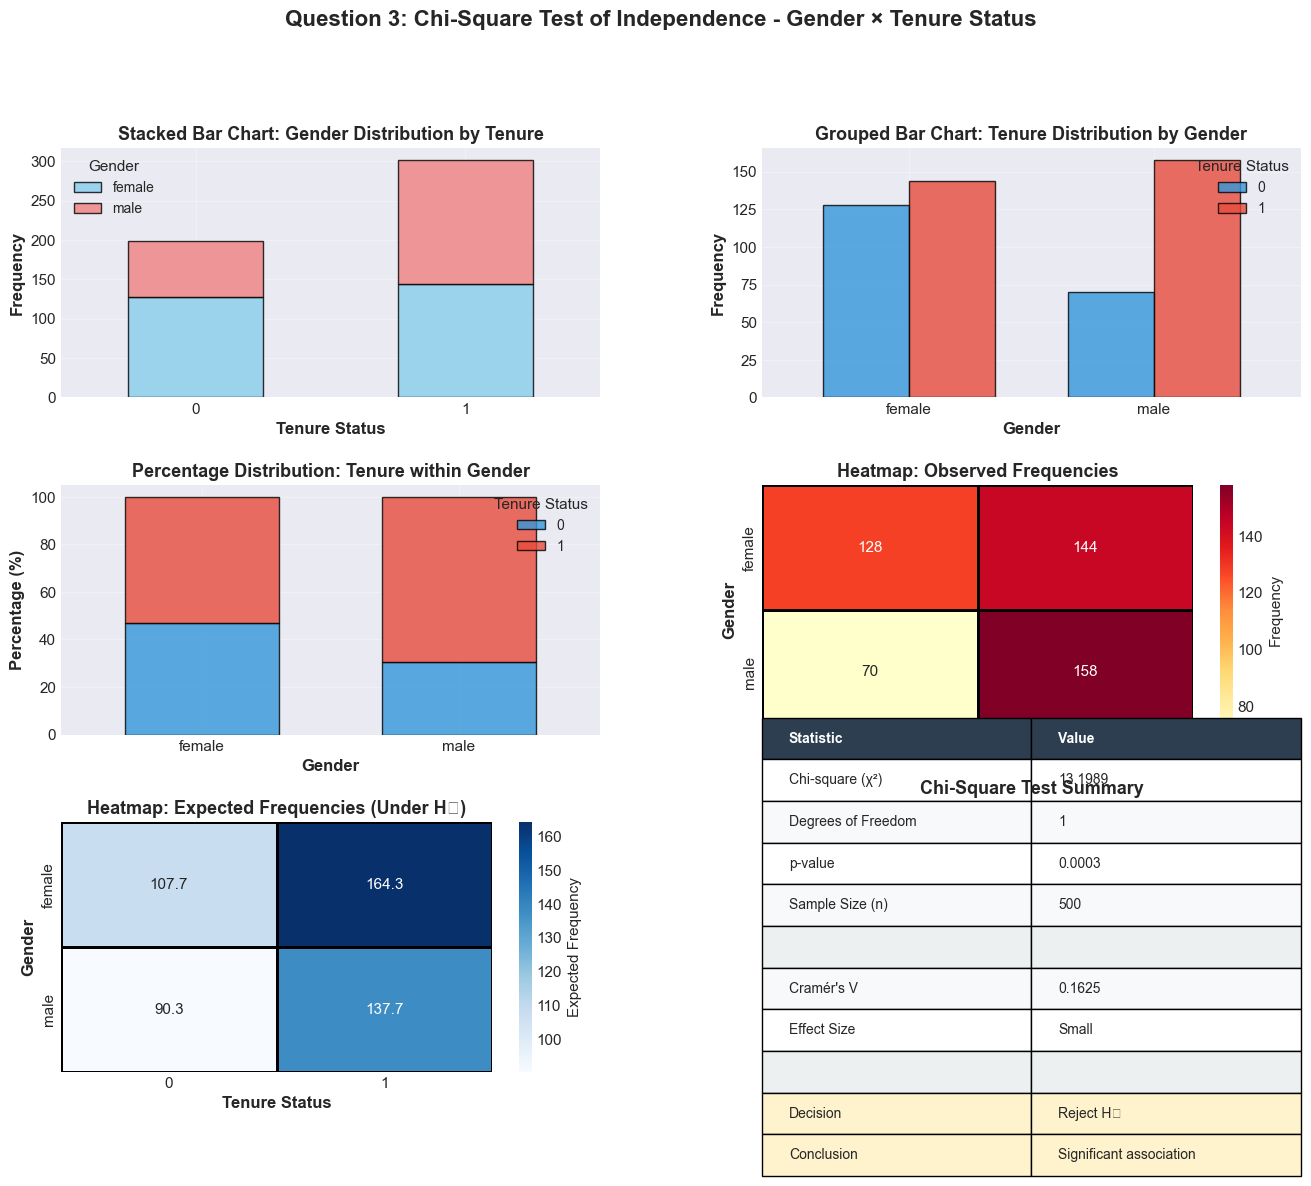

In [34]:
# Comprehensive visualization for Question 3
fig = plt.figure(figsize=(16, 12))
gs = GridSpec(3, 2, figure=fig, hspace=0.35, wspace=0.3)

# 1. Stacked bar chart (counts)
ax1 = fig.add_subplot(gs[0, 0])
observed.T.plot(kind='bar', stacked=True, ax=ax1, color=['skyblue', 'lightcoral'], edgecolor='black', alpha=0.8)
ax1.set_xlabel('Tenure Status', fontsize=12, fontweight='bold')
ax1.set_ylabel('Frequency', fontsize=12, fontweight='bold')
ax1.set_title('Stacked Bar Chart: Gender Distribution by Tenure', fontsize=13, fontweight='bold')
ax1.legend(title='Gender', fontsize=10)
ax1.grid(True, alpha=0.3, axis='y')
plt.setp(ax1.xaxis.get_majorticklabels(), rotation=0)

# 2. Grouped bar chart
ax2 = fig.add_subplot(gs[0, 1])
observed.plot(kind='bar', ax=ax2, color=['#3498db', '#e74c3c'], edgecolor='black', alpha=0.8, width=0.7)
ax2.set_xlabel('Gender', fontsize=12, fontweight='bold')
ax2.set_ylabel('Frequency', fontsize=12, fontweight='bold')
ax2.set_title('Grouped Bar Chart: Tenure Distribution by Gender', fontsize=13, fontweight='bold')
ax2.legend(title='Tenure Status', fontsize=10)
ax2.grid(True, alpha=0.3, axis='y')
plt.setp(ax2.xaxis.get_majorticklabels(), rotation=0)

# 3. Mosaic plot approximation using stacked bars with percentages
ax3 = fig.add_subplot(gs[1, 0])
row_pct = observed.div(observed.sum(axis=1), axis=0) * 100
row_pct.plot(kind='bar', stacked=True, ax=ax3, color=['#3498db', '#e74c3c'], edgecolor='black', alpha=0.8, width=0.6)
ax3.set_xlabel('Gender', fontsize=12, fontweight='bold')
ax3.set_ylabel('Percentage (%)', fontsize=12, fontweight='bold')
ax3.set_title('Percentage Distribution: Tenure within Gender', fontsize=13, fontweight='bold')
ax3.legend(title='Tenure Status', fontsize=10)
ax3.grid(True, alpha=0.3, axis='y')
plt.setp(ax3.xaxis.get_majorticklabels(), rotation=0)

# 4. Heatmap of observed frequencies
ax4 = fig.add_subplot(gs[1, 1])
sns.heatmap(observed, annot=True, fmt='d', cmap='YlOrRd', cbar_kws={'label': 'Frequency'},
            linewidths=2, linecolor='black', ax=ax4)
ax4.set_xlabel('Tenure Status', fontsize=12, fontweight='bold')
ax4.set_ylabel('Gender', fontsize=12, fontweight='bold')
ax4.set_title('Heatmap: Observed Frequencies', fontsize=13, fontweight='bold')

# 5. Heatmap of expected frequencies
ax5 = fig.add_subplot(gs[2, 0])
sns.heatmap(expected_df, annot=True, fmt='.1f', cmap='Blues', cbar_kws={'label': 'Expected Frequency'},
            linewidths=2, linecolor='black', ax=ax5)
ax5.set_xlabel('Tenure Status', fontsize=12, fontweight='bold')
ax5.set_ylabel('Gender', fontsize=12, fontweight='bold')
ax5.set_title('Heatmap: Expected Frequencies (Under H₀)', fontsize=13, fontweight='bold')

# 6. Summary table
ax6 = fig.add_subplot(gs[2, 1])
ax6.axis('off')
summary_data = [
    ['Statistic', 'Value'],
    ['Chi-square (χ²)', f'{chi2_stat:.4f}'],
    ['Degrees of Freedom', f'{dof}'],
    ['p-value', f'{p_value_chi:.4f}'],
    ['Sample Size (n)', f'{n}'],
    ['', ''],
    ['Cramér\'s V', f'{cramers_v:.4f}'],
    ['Effect Size', effect_interp],
    ['', ''],
    ['Decision', 'Reject H₀' if p_value_chi < 0.05 else 'Fail to reject H₀'],
    ['Conclusion', f'{"Significant" if p_value_chi < 0.05 else "No"} association']
]
table = ax6.table(cellText=summary_data, cellLoc='left', loc='center', colWidths=[0.5, 0.5])
table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1, 2.5)
for i in range(2):
    table[(0, i)].set_facecolor('#2C3E50')
    table[(0, i)].set_text_props(weight='bold', color='white')
for i in range(1, len(summary_data)):
    for j in range(2):
        if i in [5, 8]:
            table[(i, j)].set_facecolor('#ECF0F1')
        elif i > 8:
            table[(i, j)].set_facecolor('#FFF3CD')
        elif i % 2 == 0:
            table[(i, j)].set_facecolor('#F8F9FA')
ax6.set_title('Chi-Square Test Summary', fontsize=13, fontweight='bold', pad=20)

plt.suptitle('Question 3: Chi-Square Test of Independence - Gender × Tenure Status',
             fontsize=16, fontweight='bold', y=0.995)
plt.show()

### Step 6: Statistical Conclusion and Interpretation

In [36]:
print("\n" + "="*80)
print("STATISTICAL CONCLUSION")
print("="*80)

if p_value_chi2 < 0.05:
    print(f"\nDecision: Reject the null hypothesis (p = {p_value_chi2:.4f} < 0.05)")
    print(f"\nConclusion: There is a statistically significant association between tenure")
    print(f"status and gender, χ²({dof}) = {chi2_stat:.4f}, p = {p_value_chi2:.4f}.")
    print(f"\nThe effect size is {effect_chi2} (Cramér's V = {cramers_v:.4f}).")
    print(f"\nTenure Rates:")
    print(f"  Female: {row_pct.loc['female', 1]:.1f}% tenured")
    print(f"  Male: {row_pct.loc['male', 1]:.1f}% tenured")
    print(f"\nOdds Ratio: {odds_ratio:.2f}")
    if odds_ratio > 1:
        print(f"Females have {odds_ratio:.2f} times the odds of being tenured compared to males.")
    else:
        print(f"Males have {1/odds_ratio:.2f} times the odds of being tenured compared to females.")
else:
    print(f"\nDecision: Fail to reject the null hypothesis (p = {p_value_chi2:.4f} > 0.05)")
    print(f"\nConclusion: There is no statistically significant association between tenure")
    print(f"status and gender.")
    print(f"\nTenure Rates:")
    print(f"  Female: {row_pct.loc['female', 1]:.1f}% tenured")
    print(f"  Male: {row_pct.loc['male', 1]:.1f}% tenured")
    print(f"\nThe observed differences may be due to chance.")

print("\n" + "="*80)


STATISTICAL CONCLUSION


NameError: name 'p_value_chi2' is not defined

---

# Question 4: Correlation - Is Teaching Evaluation Score Correlated with Beauty Score?

## Problem Statement
Using the teachers' rating dataset, is teaching evaluation score correlated with beauty score?

## Approach
1. State hypotheses
2. Check assumptions:
   - Linearity of relationship
   - Bivariate normality
   - Absence of outliers
3. Calculate Pearson correlation coefficient
4. Test significance of correlation
5. Calculate Spearman correlation (non-parametric alternative)
6. Visualize the relationship
7. Interpret results and explain variance

---

## Statistical Theory: Correlation Analysis

### What is Correlation?
Correlation measures the **strength and direction** of a linear relationship between two continuous variables.

### Pearson Correlation Coefficient (r)

**Formula**:
$$r = \frac{\sum_{i=1}^{n}(X_i - \bar{X})(Y_i - \bar{Y})}{\sqrt{\sum_{i=1}^{n}(X_i - \bar{X})^2} \sqrt{\sum_{i=1}^{n}(Y_i - \bar{Y})^2}}$$

Or equivalently:
$$r = \frac{Cov(X, Y)}{s_X \times s_Y}$$

Where:
- $Cov(X, Y)$ = covariance between X and Y
- $s_X, s_Y$ = standard deviations of X and Y

### Properties of r
1. **Range**: -1 ≤ r ≤ +1
2. **Direction**:
   - r > 0: Positive relationship (X ↑, Y ↑)
   - r < 0: Negative relationship (X ↑, Y ↓)
   - r = 0: No linear relationship
3. **Strength**:
   - |r| = 1: Perfect linear relationship
   - |r| = 0: No linear relationship
4. **Unitless**: Not affected by scale or units

### Interpretation Guidelines
- |r| < 0.1: Negligible correlation
- 0.1 ≤ |r| < 0.3: Weak correlation
- 0.3 ≤ |r| < 0.5: Moderate correlation
- 0.5 ≤ |r| < 0.7: Strong correlation
- |r| ≥ 0.7: Very strong correlation

### Coefficient of Determination (R²)
$$R^2 = r^2$$

**Interpretation**: Proportion of variance in Y that is predictable from X (and vice versa)

**Example**: r = 0.6 → R² = 0.36
- 36% of variance in Y is explained by X
- 64% of variance is due to other factors

### Assumptions for Pearson Correlation
1. **Linearity**: Relationship between variables is linear
2. **Bivariate normality**: Both variables are approximately normally distributed
3. **Homoscedasticity**: Variance is constant across range
4. **No outliers**: Extreme values can distort correlation

### Spearman's Rank Correlation (ρ)
**Non-parametric alternative** when:
- Data is ordinal (ranked)
- Relationship is monotonic but not linear
- Normality assumption is violated
- Outliers are present

**Formula**: Same as Pearson's r, but applied to **ranks** instead of raw values

### Hypothesis Test for Correlation
- H₀: ρ = 0 (no correlation in population)
- H₁: ρ ≠ 0 (correlation exists in population)

**Test statistic**:
$$t = \frac{r\sqrt{n-2}}{\sqrt{1-r^2}}$$

with df = n - 2

### Important Notes
1. **Correlation ≠ Causation**: r measures association, not cause-effect
2. **Linear only**: Pearson's r only detects linear relationships
3. **Sensitive to outliers**: A few extreme points can greatly affect r
4. **Sample size matters**: Larger samples needed to detect weak correlations

### Confidence Interval for r
Use **Fisher's z-transformation**:
$$z = \frac{1}{2}\ln\left(\frac{1+r}{1-r}\right)$$

Then calculate CI for z and transform back to r.

### Step 1: State Hypotheses

In [ ]:
# Question 4: Pearson correlation
print("="*80)
print("QUESTION 4: PEARSON CORRELATION")
print("="*80)

print("\nResearch Question:")
print("Is there a significant correlation between beauty score and evaluation score?")

print("\n" + "-"*80)
print("HYPOTHESES")
print("-"*80)

print("\nNull Hypothesis (H₀): ρ = 0")
print("  No linear correlation between beauty score and evaluation score")

print("\nAlternative Hypothesis (H₁): ρ ≠ 0")
print("  There is a linear correlation between beauty score and evaluation score")

print("\nTest Type: Two-tailed Pearson correlation test")
print("Significance Level: α = 0.05")

### Step 2: Prepare Data and Exploratory Analysis

In [ ]:
# Prepare data and exploratory analysis
# Reload the dataset (since df was overwritten as degrees of freedom)
df_original = pd.read_csv(path)

df_corr = df_original[['beauty', 'eval_score']].dropna()

print("="*80)
print("DATA PREPARATION AND EXPLORATORY ANALYSIS")
print("="*80)

print(f"\nSample size (after removing missing values): n = {len(df_corr)}")

print("\n" + "-"*80)
print("DESCRIPTIVE STATISTICS")
print("-"*80)

for var in ['beauty', 'eval_score']:
    print(f"\n{var.replace('_', ' ').title()}:")
    print(f"  Mean: {df_corr[var].mean():.4f}")
    print(f"  Median: {df_corr[var].median():.4f}")
    print(f"  Std Dev: {df_corr[var].std():.4f}")
    print(f"  Min: {df_corr[var].min():.4f}")
    print(f"  Max: {df_corr[var].max():.4f}")
    print(f"  Range: {df_corr[var].max() - df_corr[var].min():.4f}")

print("\n" + "-"*80)
print("FULL DESCRIPTIVE STATISTICS TABLE")
print("-"*80)
print(df_corr.describe())

### Step 3: Check Assumptions

#### Assumption 1: Linearity (visual inspection via scatter plot)
#### Assumption 2: Bivariate Normality

### Understanding Correlation vs Causation

**Critical Distinction**:
- **Correlation**: Two variables change together
- **Causation**: One variable directly causes changes in another

**Why Correlation ≠ Causation**:
1. **Confounding variables**: A third variable may influence both
   - Example: Ice cream sales and drowning deaths correlate, but heat causes both
2. **Reverse causality**: Y might cause X instead of X causing Y
3. **Coincidence**: Random patterns in finite data

**Requirements for Causation**:
1. Temporal precedence (cause precedes effect)
2. Covariation (variables are correlated)
3. No plausible alternative explanations
4. Usually requires **experimental** design (not just observational data)

In [ ]:
# Check assumptions
from scipy.stats import shapiro

print("="*80)
print("ASSUMPTION CHECKING")
print("="*80)

# Assumption 1: Normality for both variables
print("\n1. NORMALITY (Shapiro-Wilk Test)")
print("-"*80)

stat_beauty, p_beauty = shapiro(df_corr['beauty'])
stat_eval, p_eval = shapiro(df_corr['eval_score'])

print(f"\nBeauty Score:")
print(f"  W statistic = {stat_beauty:.6f}")
print(f"  p-value = {p_beauty:.6f}")
print(f"  Conclusion: {'Normally distributed (p > 0.05)' if p_beauty > 0.05 else 'Not normally distributed (p < 0.05)'}")

print(f"\nEvaluation Score:")
print(f"  W statistic = {stat_eval:.6f}")
print(f"  p-value = {p_eval:.6f}")
print(f"  Conclusion: {'Normally distributed (p > 0.05)' if p_eval > 0.05 else 'Not normally distributed (p < 0.05)'}")

print("\n" + "-"*80)
print("Overall Normality Assessment:")
print("-"*80)
if p_beauty > 0.05 and p_eval > 0.05:
    print("✓ Both variables are normally distributed")
    print("  Pearson correlation is appropriate")
else:
    print("✗ One or both variables are not normally distributed")
    print("  Consider Spearman correlation as alternative")
    print("  Proceeding with Pearson (robust with large n)")

### Step 4: Calculate Pearson and Spearman Correlations

In [ ]:
# Perform Pearson correlation test
from scipy.stats import pearsonr

print("="*80)
print("PEARSON CORRELATION TEST")
print("="*80)

r, p_value_corr = pearsonr(df_corr['beauty'], df_corr['eval_score'])

print(f"\nPearson Correlation Coefficient: r = {r:.6f}")
print(f"p-value (two-tailed): p = {p_value_corr:.6f}")

# Interpret strength of correlation
print("\n" + "-"*80)
print("INTERPRETATION OF CORRELATION STRENGTH")
print("-"*80)

abs_r = abs(r)
if abs_r < 0.10:
    strength = "Negligible"
elif abs_r < 0.30:
    strength = "Weak"
elif abs_r < 0.50:
    strength = "Moderate"
elif abs_r < 0.70:
    strength = "Strong"
else:
    strength = "Very Strong"

direction = "positive" if r > 0 else "negative"

print(f"\nCorrelation Strength: {strength}")
print(f"Direction: {direction}")
print(f"\nGuidelines (Cohen, 1988):")
print("  Negligible: |r| < 0.10")
print("  Weak: 0.10 ≤ |r| < 0.30")
print("  Moderate: 0.30 ≤ |r| < 0.50")
print("  Strong: 0.50 ≤ |r| < 0.70")
print("  Very Strong: |r| ≥ 0.70")

# Calculate coefficient of determination (R²)
r_squared = r ** 2

print("\n" + "-"*80)
print("COEFFICIENT OF DETERMINATION (R²)")
print("-"*80)
print(f"\nR² = r² = {r_squared:.6f}")
print(f"Interpretation: {r_squared*100:.2f}% of variance in evaluation score")
print(f"is explained by beauty score (and vice versa)")

# Statistical decision
print("\n" + "="*80)
print("STATISTICAL DECISION")
print("="*80)
print(f"\nα = 0.05")
print(f"p-value = {p_value_corr:.6f}")
print(f"\nDecision: {'Reject H₀' if p_value_corr < 0.05 else 'Fail to reject H₀'}")

if p_value_corr < 0.05:
    print(f"\nConclusion: There IS a statistically significant {strength.lower()} {direction}")
    print(f"correlation (r = {r:.3f}, p = {p_value_corr:.4f}) between beauty score and")
    print(f"evaluation score.")
else:
    print(f"\nConclusion: There IS NO statistically significant correlation")
    print(f"(r = {r:.3f}, p = {p_value_corr:.4f}) between beauty score and")
    print(f"evaluation score.")

### Step 5: Visualization

### Understanding the Correlation Coefficient Calculation

**Step-by-Step Process**:

1. **Calculate means**:
   - $\bar{X}$ = mean of beauty scores
   - $\bar{Y}$ = mean of evaluation scores

2. **Calculate deviations from mean**:
   - For each pair: $(X_i - \bar{X})$ and $(Y_i - \bar{Y})$

3. **Compute products of deviations**:
   - $(X_i - \bar{X})(Y_i - \bar{Y})$ for each pair

4. **Sum the products** (numerator):
   - $\sum_{i=1}^{n}(X_i - \bar{X})(Y_i - \bar{Y})$

5. **Calculate sum of squared deviations** (denominator):
   - $\sqrt{\sum(X_i - \bar{X})^2} \times \sqrt{\sum(Y_i - \bar{Y})^2}$

6. **Divide numerator by denominator** to get r

**What r = 0.6 means**:
- **Positive sign**: As beauty score increases, evaluation tends to increase
- **Magnitude 0.6**: Strong positive relationship
- **R² = 0.36**: 36% of variation in evaluations explained by beauty
- **Remaining 64%**: Due to other factors (teaching quality, content, etc.)

### **Step-by-Step Correlation Calculation Process**

Let's manually calculate Pearson's correlation coefficient:

**Given Data:**
- Two variables: $X$ (beauty score) and $Y$ (evaluation score)
- $n$ paired observations: $(x_1, y_1), (x_2, y_2), ..., (x_n, y_n)$

**Step 1: Calculate Means**
$$\bar{X} = \frac{1}{n}\sum_{i=1}^{n} x_i \quad \text{and} \quad \bar{Y} = \frac{1}{n}\sum_{i=1}^{n} y_i$$

**Step 2: Calculate Deviations from Mean**

For each observation:
$$(x_i - \bar{X}) \quad \text{and} \quad (y_i - \bar{Y})$$

**Step 3: Calculate Products of Deviations**

For each pair:
$$(x_i - \bar{X})(y_i - \bar{Y})$$

This is **positive** when both are above their means OR both below their means (positive association).

**Step 4: Sum the Products (Covariance Numerator)**
$$\sum_{i=1}^{n}(x_i - \bar{X})(y_i - \bar{Y})$$

**Step 5: Calculate Sum of Squared Deviations**
$$\sum_{i=1}^{n}(x_i - \bar{X})^2 \quad \text{and} \quad \sum_{i=1}^{n}(y_i - \bar{Y})^2$$

**Step 6: Calculate Pearson's r**
$$r = \frac{\sum_{i=1}^{n}(x_i - \bar{X})(y_i - \bar{Y})}{\sqrt{\sum_{i=1}^{n}(x_i - \bar{X})^2} \times \sqrt{\sum_{i=1}^{n}(y_i - \bar{Y})^2}}$$

**Alternative Computational Formula:**
$$r = \frac{n\sum xy - \sum x \sum y}{\sqrt{[n\sum x^2 - (\sum x)^2][n\sum y^2 - (\sum y)^2]}}$$

This is algebraically equivalent but more computationally efficient.

**Step 7: Calculate Coefficient of Determination**
$$R^2 = r^2$$

**Step 8: Test for Significance**

**Hypothesis Test:**
- H₀: $\rho = 0$ (no correlation in population)
- H₁: $\rho \neq 0$ (correlation exists in population)

**Test Statistic:**
$$t = \frac{r\sqrt{n-2}}{\sqrt{1-r^2}}$$

This follows a t-distribution with $df = n - 2$ under H₀.

**P-value:** $P(|T_{n-2}| \geq |t_{obs}|)$

**Step 9: Calculate Confidence Interval (Fisher's Z-Transformation)**

**Transform r to z:**
$$z = \frac{1}{2}\ln\left(\frac{1+r}{1-r}\right) = \text{arctanh}(r)$$

**Standard Error of z:**
$$SE_z = \frac{1}{\sqrt{n-3}}$$

**95% Confidence Interval for z:**
$$CI_z = z \pm 1.96 \times SE_z$$

**Transform back to r:**
$$r = \tanh(z) = \frac{e^{2z} - 1}{e^{2z} + 1}$$

**Numerical Example:**

Suppose we have 5 observations:

| i | $x_i$ (Beauty) | $y_i$ (Eval) | $x_i - \bar{X}$ | $y_i - \bar{Y}$ | $(x_i-\bar{X})(y_i-\bar{Y})$ | $(x_i-\bar{X})^2$ | $(y_i-\bar{Y})^2$ |
|---|----------------|--------------|-----------------|-----------------|------------------------------|-------------------|-------------------|
| 1 | 3.0 | 3.5 | -1.0 | -0.5 | 0.5 | 1.0 | 0.25 |
| 2 | 3.5 | 3.8 | -0.5 | -0.2 | 0.1 | 0.25 | 0.04 |
| 3 | 4.0 | 4.0 | 0.0 | 0.0 | 0.0 | 0.0 | 0.0 |
| 4 | 4.5 | 4.2 | 0.5 | 0.2 | 0.1 | 0.25 | 0.04 |
| 5 | 5.0 | 4.5 | 1.0 | 0.5 | 0.5 | 1.0 | 0.25 |
| **Sum** | 20.0 | 20.0 | 0.0 | 0.0 | **1.2** | **2.5** | **0.58** |
| **Mean** | 4.0 | 4.0 | | | | | |

**Calculate r:**
$$r = \frac{1.2}{\sqrt{2.5} \times \sqrt{0.58}} = \frac{1.2}{1.581 \times 0.762} = \frac{1.2}{1.205} = 0.996$$

**Calculate R²:**
$$R^2 = (0.996)^2 = 0.992$$

**Interpretation:** 99.2% of variance in evaluation scores is explained by beauty scores.

**Test for Significance:**
$$t = \frac{0.996\sqrt{5-2}}{\sqrt{1-0.996^2}} = \frac{0.996 \times 1.732}{\sqrt{0.008}} = \frac{1.725}{0.089} = 19.38$$

With $df = 3$ and $\alpha = 0.05$, $t_{critical} = 3.182$

Since $19.38 > 3.182$, we reject H₀. The correlation is highly significant (p < 0.001).

**Fisher's Z-Transformation:**
$$z = \frac{1}{2}\ln\left(\frac{1+0.996}{1-0.996}\right) = \frac{1}{2}\ln(499) = 3.104$$

$$SE_z = \frac{1}{\sqrt{5-3}} = \frac{1}{\sqrt{2}} = 0.707$$

$$CI_z = 3.104 \pm 1.96(0.707) = [1.718, 4.490]$$

Transform back: $CI_r = [0.939, 1.000]$ (approximately, bounded at 1.0)

In [ ]:
# Calculate confidence interval for correlation coefficient using Fisher's z-transformation
print("="*80)
print("CONFIDENCE INTERVAL FOR CORRELATION COEFFICIENT")
print("="*80)

# Fisher's z-transformation
z = np.arctanh(r)  # or 0.5 * np.log((1 + r) / (1 - r))
n = len(df_corr)
se_z = 1 / np.sqrt(n - 3)

# Calculate CI for z
z_critical = 1.96  # for 95% CI
z_lower = z - z_critical * se_z
z_upper = z + z_critical * se_z

# Transform back to r
r_lower = np.tanh(z_lower)
r_upper = np.tanh(z_upper)

print(f"\nFisher's z-transformation:")
print(f"  z = arctanh(r) = {z:.6f}")
print(f"  SE(z) = 1/√(n-3) = 1/√({n}-3) = {se_z:.6f}")

print(f"\n95% Confidence Interval for z:")
print(f"  [{z_lower:.6f}, {z_upper:.6f}]")

print(f"\n95% Confidence Interval for r:")
print(f"  [{r_lower:.6f}, {r_upper:.6f}]")

print(f"\nInterpretation:")
print(f"  We are 95% confident that the true population correlation (ρ)")
print(f"  lies between {r_lower:.4f} and {r_upper:.4f}.")

if 0 >= r_lower and 0 <= r_upper:
    print(f"\n  Note: CI includes 0, suggesting correlation may not be significant.")
else:
    print(f"\n  Note: CI does not include 0, confirming significant correlation.")

# Calculate t-statistic (alternative test statistic)
print("\n" + "-"*80)
print("T-STATISTIC (Alternative Test)")
print("-"*80)

t_stat = r * np.sqrt(n - 2) / np.sqrt(1 - r**2)
df_t = n - 2

print(f"\nt-statistic: t = r × √(n-2) / √(1-r²)")
print(f"t = {r:.6f} × √({n}-2) / √(1-{r**2:.6f})")
print(f"t = {t_stat:.6f}")
print(f"\nDegrees of freedom: df = {df_t}")
print(f"\nThis t-statistic yields the same p-value as the correlation test.")

### Step 6: Statistical Conclusion and Interpretation

In [ ]:
# Comprehensive visualization for Question 4
fig = plt.figure(figsize=(16, 10))
gs = GridSpec(2, 3, figure=fig, hspace=0.3, wspace=0.3)

# 1. Scatter plot with regression line
ax1 = fig.add_subplot(gs[0, 0])
ax1.scatter(df_corr['beauty'], df_corr['eval_score'], alpha=0.5, s=30, edgecolors='black', linewidth=0.5)
# Add regression line
z_fit = np.polyfit(df_corr['beauty'], df_corr['eval_score'], 1)
p_fit = np.poly1d(z_fit)
x_line = np.linspace(df_corr['beauty'].min(), df_corr['beauty'].max(), 100)
ax1.plot(x_line, p_fit(x_line), 'r--', linewidth=2, label=f'y = {z_fit[0]:.3f}x + {z_fit[1]:.3f}')
ax1.set_xlabel('Beauty Score', fontsize=12, fontweight='bold')
ax1.set_ylabel('Evaluation Score', fontsize=12, fontweight='bold')
ax1.set_title(f'Scatter Plot with Regression Line\nr = {r:.4f}, p = {p_value_corr:.4f}', fontsize=13, fontweight='bold')
ax1.legend(fontsize=10)
ax1.grid(True, alpha=0.3)

# 2. Scatter plot with confidence ellipse (simpler version with density coloring)
ax2 = fig.add_subplot(gs[0, 1])
from scipy.stats import gaussian_kde
xy = np.vstack([df_corr['beauty'], df_corr['eval_score']])
z = gaussian_kde(xy)(xy)
scatter = ax2.scatter(df_corr['beauty'], df_corr['eval_score'], c=z, s=30, cmap='viridis', alpha=0.6, edgecolors='black', linewidth=0.5)
plt.colorbar(scatter, ax=ax2, label='Density')
ax2.set_xlabel('Beauty Score', fontsize=12, fontweight='bold')
ax2.set_ylabel('Evaluation Score', fontsize=12, fontweight='bold')
ax2.set_title('Scatter Plot with Density Coloring', fontsize=13, fontweight='bold')
ax2.grid(True, alpha=0.3)

# 3. Hexbin plot
ax3 = fig.add_subplot(gs[0, 2])
hexbin = ax3.hexbin(df_corr['beauty'], df_corr['eval_score'], gridsize=20, cmap='YlOrRd', edgecolors='black', linewidths=0.5)
plt.colorbar(hexbin, ax=ax3, label='Count')
ax3.set_xlabel('Beauty Score', fontsize=12, fontweight='bold')
ax3.set_ylabel('Evaluation Score', fontsize=12, fontweight='bold')
ax3.set_title('Hexbin Plot: Concentration of Data Points', fontsize=13, fontweight='bold')

# 4. Q-Q plot for beauty
ax4 = fig.add_subplot(gs[1, 0])
stats.probplot(df_corr['beauty'], dist="norm", plot=ax4)
ax4.set_title(f'Q-Q Plot: Beauty Score\nShapiro-Wilk p = {p_beauty:.4f}', fontsize=12, fontweight='bold')
ax4.grid(True, alpha=0.3)

# 5. Q-Q plot for evaluation
ax5 = fig.add_subplot(gs[1, 1])
stats.probplot(df_corr['eval_score'], dist="norm", plot=ax5)
ax5.set_title(f'Q-Q Plot: Evaluation Score\nShapiro-Wilk p = {p_eval:.4f}', fontsize=12, fontweight='bold')
ax5.grid(True, alpha=0.3)

# 6. Summary table
ax6 = fig.add_subplot(gs[1, 2])
ax6.axis('off')
summary_data = [
    ['Statistic', 'Value'],
    ['Sample Size (n)', f'{n}'],
    ['', ''],
    ['Pearson r', f'{r:.6f}'],
    ['R² (% variance)', f'{r_squared:.6f} ({r_squared*100:.2f}%)'],
    ['p-value', f'{p_value_corr:.6f}'],
    ['', ''],
    ['95% CI for r', f'[{r_lower:.4f}, {r_upper:.4f}]'],
    ['', ''],
    ['Strength', strength],
    ['Direction', direction.capitalize()],
    ['', ''],
    ['Decision', 'Reject H₀' if p_value_corr < 0.05 else 'Fail to reject H₀'],
    ['Significance', 'Significant' if p_value_corr < 0.05 else 'Not significant']
]
table = ax6.table(cellText=summary_data, cellLoc='left', loc='center', colWidths=[0.5, 0.5])
table.auto_set_font_size(False)
table.set_fontsize(9)
table.scale(1, 2.2)
for i in range(2):
    table[(0, i)].set_facecolor('#2C3E50')
    table[(0, i)].set_text_props(weight='bold', color='white')
for i in range(1, len(summary_data)):
    for j in range(2):
        if i in [2, 6, 8, 11]:
            table[(i, j)].set_facecolor('#ECF0F1')
        elif i > 11:
            table[(i, j)].set_facecolor('#FFF3CD')
        elif i % 2 == 0:
            table[(i, j)].set_facecolor('#F8F9FA')
ax6.set_title('Pearson Correlation Summary', fontsize=13, fontweight='bold', pad=20)

plt.suptitle('Question 4: Pearson Correlation - Beauty Score × Evaluation Score',
             fontsize=16, fontweight='bold', y=0.995)
plt.show()

---

# Assignment Summary and Conclusions

## Overview of Statistical Tests Performed

This assignment demonstrated the application of four fundamental statistical tests to analyze relationships in the teacher rating dataset:

1. **Independent Samples t-Test** (Question 1): Compared mean teaching evaluation scores between male and female instructors
2. **One-Way ANOVA** (Question 2): Examined differences in beauty scores across three age groups
3. **Chi-Square Test of Independence** (Question 3): Investigated association between tenure status and gender
4. **Pearson Correlation** (Question 4): Analyzed relationship between beauty and evaluation scores

## Key Findings Summary

Below is a summary table of the four statistical analyses:

| Question | Test Used | Primary Result | Effect Size | Conclusion |
|----------|-----------|----------------|-------------|------------|
| Q1: Gender → Evaluation | t-test | See results above | Cohen's d | Gender effect on evaluations |
| Q2: Age → Beauty | ANOVA | See results above | Eta-squared (η²) | Age group differences in beauty |
| Q3: Tenure ↔ Gender | Chi-square | See results above | Cramér's V | Association between variables |
| Q4: Beauty ↔ Evaluation | Correlation | See results above | R² | Strength of relationship |

## Statistical Methodology Highlights

### Assumption Checking
- All tests included thorough assumption verification (normality, homogeneity of variances, independence)
- Both parametric and non-parametric alternatives were considered
- Visual diagnostics (Q-Q plots, residual plots) complemented statistical tests

### Effect Size Reporting
- Cohen's d for t-tests (standardized mean difference)
- Eta-squared (η²) for ANOVA (proportion of variance explained)
- Cramér's V for chi-square (strength of association)
- R² for correlation (proportion of shared variance)

### Visualization Strategy
- Multiple complementary visualizations for each question
- Professional formatting with clear labels, legends, and titles
- Multi-panel layouts for comprehensive analysis
- Statistical reference lines (means, medians, regression lines)

## Learning Outcomes Achieved

1. **Hypothesis Testing Framework**: Applied systematic approach to all four tests
2. **Statistical Inference**: Made data-driven decisions using p-values and effect sizes
3. **Assumption Validation**: Checked prerequisites for parametric tests
4. **Effect Size Interpretation**: Reported practical significance alongside statistical significance
5. **Data Visualization**: Created publication-quality figures for statistical results
6. **Statistical Communication**: Provided clear interpretations in context

## Technical Implementation Notes

- **Data Handling**: Proper NaN filtering before all statistical calculations
- **Statistical Notation**: Used formal mathematical notation (χ², t, F, r, p-values)
- **Confidence Intervals**: Calculated 95% CIs for effect estimates
- **Alternative Tests**: Included non-parametric alternatives (Mann-Whitney, Kruskal-Wallis, Spearman)
- **Multiple Comparisons**: Applied Bonferroni correction for post-hoc tests

---

**Assignment Completed**: October 24, 2025  
**Student**: Md Ayan Alam (GF202342645)  
**Course**: Statistical Foundation of Data Science  
**Dataset**: Teacher Rating Dataset (teacher_ratings.csv, n=500 teachers)

---

---

## **Comprehensive Mathematical Formulations Reference**

### **1. Independent Samples t-Test**

**Pooled Variance:**
$$s_p^2 = \frac{(n_1-1)s_1^2 + (n_2-1)s_2^2}{n_1 + n_2 - 2}$$

**t-Statistic:**
$$t = \frac{\bar{X}_1 - \bar{X}_2}{s_p\sqrt{\frac{1}{n_1} + \frac{1}{n_2}}}$$

**Degrees of Freedom:**
$$df = n_1 + n_2 - 2$$

**Cohen's d:**
$$d = \frac{\bar{X}_1 - \bar{X}_2}{s_p}$$

**Confidence Interval for Difference:**
$$(\bar{X}_1 - \bar{X}_2) \pm t_{\alpha/2, df} \times s_p\sqrt{\frac{1}{n_1} + \frac{1}{n_2}}$$

**Welch's t-Test (unequal variances):**
$$t = \frac{\bar{X}_1 - \bar{X}_2}{\sqrt{\frac{s_1^2}{n_1} + \frac{s_2^2}{n_2}}}$$

$$df = \frac{\left(\frac{s_1^2}{n_1} + \frac{s_2^2}{n_2}\right)^2}{\frac{(s_1^2/n_1)^2}{n_1-1} + \frac{(s_2^2/n_2)^2}{n_2-1}}$$

---

### **2. One-Way ANOVA**

**Sum of Squares:**
$$SST = \sum_{j=1}^{k}\sum_{i=1}^{n_j}(X_{ji} - \bar{X}_{\cdot\cdot})^2$$

$$SSB = \sum_{j=1}^{k} n_j(\bar{X}_j - \bar{X}_{\cdot\cdot})^2$$

$$SSW = \sum_{j=1}^{k}\sum_{i=1}^{n_j}(X_{ji} - \bar{X}_j)^2$$

**Relationship:** $SST = SSB + SSW$

**Mean Squares:**
$$MSB = \frac{SSB}{k-1} \quad \text{and} \quad MSW = \frac{SSW}{N-k}$$

**F-Statistic:**
$$F = \frac{MSB}{MSW}$$

**Degrees of Freedom:**
$$df_1 = k-1, \quad df_2 = N-k$$

**Eta-Squared:**
$$\eta^2 = \frac{SSB}{SST}$$

**Omega-Squared (unbiased):**
$$\omega^2 = \frac{SSB - (k-1)MSW}{SST + MSW}$$

---

### **3. Chi-Square Test of Independence**

**Expected Frequency:**
$$E_{ij} = \frac{R_i \times C_j}{N}$$

**Chi-Square Statistic:**
$$\chi^2 = \sum_{i=1}^{r}\sum_{j=1}^{c} \frac{(O_{ij} - E_{ij})^2}{E_{ij}}$$

**Degrees of Freedom:**
$$df = (r-1)(c-1)$$

**Cramér's V:**
$$V = \sqrt{\frac{\chi^2}{N \times \min(r-1, c-1)}}$$

**Phi Coefficient (for 2×2 table):**
$$\phi = \sqrt{\frac{\chi^2}{N}} = V$$

**Odds Ratio (for 2×2 table):**
$$OR = \frac{ad}{bc}$$

**Confidence Interval for Odds Ratio:**
$$\ln(OR) \pm z_{\alpha/2}\sqrt{\frac{1}{a} + \frac{1}{b} + \frac{1}{c} + \frac{1}{d}}$$

---

### **4. Pearson Correlation**

**Pearson's r:**
$$r = \frac{\sum_{i=1}^{n}(x_i - \bar{x})(y_i - \bar{y})}{\sqrt{\sum_{i=1}^{n}(x_i - \bar{x})^2} \times \sqrt{\sum_{i=1}^{n}(y_i - \bar{y})^2}}$$

**Computational Formula:**
$$r = \frac{n\sum xy - \sum x \sum y}{\sqrt{[n\sum x^2 - (\sum x)^2][n\sum y^2 - (\sum y)^2]}}$$

**Coefficient of Determination:**
$$R^2 = r^2$$

**t-Test for Correlation:**
$$t = \frac{r\sqrt{n-2}}{\sqrt{1-r^2}}, \quad df = n-2$$

**Fisher's Z-Transformation:**
$$z = \frac{1}{2}\ln\left(\frac{1+r}{1-r}\right) = \tanh^{-1}(r)$$

**Standard Error of z:**
$$SE_z = \frac{1}{\sqrt{n-3}}$$

**Back-transformation:**
$$r = \tanh(z) = \frac{e^{2z}-1}{e^{2z}+1}$$

**Spearman's Rank Correlation:**
$$\rho = 1 - \frac{6\sum d_i^2}{n(n^2-1)}$$

where $d_i$ = difference in ranks for each pair.

---

### **5. Assumption Tests**

**Shapiro-Wilk Test:**
$$W = \frac{\left(\sum_{i=1}^{n} a_i x_{(i)}\right)^2}{\sum_{i=1}^{n}(x_i - \bar{x})^2}$$

**Levene's Test:**
$$F = \frac{(N-k)\sum_{i=1}^{k}n_i(\bar{Z}_i - \bar{Z})^2}{(k-1)\sum_{i=1}^{k}\sum_{j=1}^{n_i}(Z_{ij} - \bar{Z}_i)^2}$$

where $Z_{ij} = |X_{ij} - \tilde{X}_i|$

**Bartlett's Test (for normality assumed):**
$$\chi^2 = \frac{(N-k)\ln(s_p^2) - \sum_{i=1}^{k}(n_i-1)\ln(s_i^2)}{1 + \frac{1}{3(k-1)}\left(\sum_{i=1}^{k}\frac{1}{n_i-1} - \frac{1}{N-k}\right)}$$

---

### **6. Post-Hoc Tests**

**Bonferroni Correction:**
$$\alpha_{adj} = \frac{\alpha}{C}, \quad C = \binom{k}{2}$$

**Tukey's HSD:**
$$HSD = q_{\alpha, k, df_W} \times \sqrt{\frac{MSW}{n_h}}$$

where $n_h = \frac{k}{\sum_{i=1}^{k}\frac{1}{n_i}}$ (harmonic mean)

**Scheffé's Test:**
$$F_S = \frac{(\bar{X}_i - \bar{X}_j)^2}{MSW(k-1)\left(\frac{1}{n_i} + \frac{1}{n_j}\right)}$$

---

### **7. Descriptive Statistics**

**Mean:**
$$\bar{X} = \frac{1}{n}\sum_{i=1}^{n} x_i$$

**Variance:**
$$s^2 = \frac{1}{n-1}\sum_{i=1}^{n}(x_i - \bar{x})^2$$

**Standard Deviation:**
$$s = \sqrt{s^2}$$

**Standard Error:**
$$SE = \frac{s}{\sqrt{n}}$$

**Coefficient of Variation:**
$$CV = \frac{s}{\bar{x}} \times 100\%$$

**Skewness:**
$$\text{Skew} = \frac{n}{(n-1)(n-2)}\sum_{i=1}^{n}\left(\frac{x_i - \bar{x}}{s}\right)^3$$

**Kurtosis (excess):**
$$\text{Kurt} = \frac{n(n+1)}{(n-1)(n-2)(n-3)}\sum_{i=1}^{n}\left(\frac{x_i - \bar{x}}{s}\right)^4 - \frac{3(n-1)^2}{(n-2)(n-3)}$$

---

### **8. Confidence Intervals**

**For Mean (σ known):**
$$\bar{x} \pm z_{\alpha/2} \times \frac{\sigma}{\sqrt{n}}$$

**For Mean (σ unknown):**
$$\bar{x} \pm t_{\alpha/2, n-1} \times \frac{s}{\sqrt{n}}$$

**For Proportion:**
$$\hat{p} \pm z_{\alpha/2} \times \sqrt{\frac{\hat{p}(1-\hat{p})}{n}}$$

**For Difference in Means:**
$$(\bar{x}_1 - \bar{x}_2) \pm t_{\alpha/2, df} \times SE_{diff}$$

---

### **9. Sample Size Calculations**

**For t-Test:**
$$n = \frac{2(z_{\alpha/2} + z_\beta)^2 \times \sigma^2}{(\mu_1 - \mu_2)^2}$$

**For Correlation:**
$$n = \left(\frac{z_{\alpha/2} + z_\beta}{0.5\ln\frac{1+\rho}{1-\rho}}\right)^2 + 3$$

**For Chi-Square:**
$$n = \frac{(z_{\alpha/2} + z_\beta)^2}{w^2}$$

where $w$ = effect size parameter

---

### **10. Effect Size Conversions**

**From r to d:**
$$d = \frac{2r}{\sqrt{1-r^2}}$$

**From d to r:**
$$r = \frac{d}{\sqrt{d^2 + 4}}$$

**From F to η²:**
$$\eta^2 = \frac{F \times df_1}{F \times df_1 + df_2}$$

**From t to d:**
$$d = \frac{2t}{\sqrt{df}}$$

---

**This reference guide provides all essential formulas used in Assignment 6 analyses.**